In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
 def prepare_data_for_ks_test_single(file, skip, teff_min, teff_max, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)
    #print(df.columns)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    df_combined = pd.concat([df_combined, df], ignore_index=True)

    plt.scatter(df['pl_rade'], df['st_teff'], alpha=0.5, label=file)
    if 'pl_name' in df.columns:
        for i, txt in enumerate(df['pl_name']):
            plt.annotate(txt, (df['pl_rade'].iloc[i], df['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_combined[['pl_rade', 'st_teff']], len(df_combined)

def perform_ks_test(file1, skip1, file2, skip2, teff_min1=3000, teff_max1=3200, teff_min2=3200, teff_max2=3400, rad_min1=0, rad_max1=10, rad_min2=0, rad_max2=10):
   

    data_for_ks_test_1, file_1_len = prepare_data_for_ks_test_single(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
    data_for_ks_test_2, file_2_len = prepare_data_for_ks_test_single(file2, skip2 ,teff_min2, teff_max2, rad_min2, rad_max2)

    from scipy.stats import ks_2samp

    #print('≤ 0 as indicating no agreement and 0.01–0.20 as none to slight, 0.21–0.40 as fair, 0.41– 0.60 as moderate, 0.61–0.80 as substantial, and 0.81–1.00 as almost perfect agreement.\nlower p value, more different\n')


    print(f"File 1: {file1}\n{file_1_len} planets, Teff {teff_min1} - {teff_max1} K\n")
    print(f"File 2: {file2}:\n{file_2_len} planets, Teff {teff_min2} - {teff_max2} K\n")


    # Perform KS test on 'pl_rade' column
    ks_statistic_rade, p_value_rade = ks_2samp(data_for_ks_test_1['pl_rade'], data_for_ks_test_2['pl_rade'])
    print(f"KS Statistic for 'pl_rade': {ks_statistic_rade}, P-value: {p_value_rade}")

    # Perform KS test on 'st_teff' column
    ks_statistic_teff, p_value_teff = ks_2samp(data_for_ks_test_1['st_teff'], data_for_ks_test_2['st_teff'])
    print(f"KS Statistic for 'st_teff': {ks_statistic_teff}, P-value: {p_value_teff}")


    # Plot histograms for 'pl_rade' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['pl_rade'], bins=20, alpha=0.5,  label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Planetary Radius (pl_rade)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()


    # Plot histograms for 'st_teff' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_ks_test_1['st_teff'], bins=20, alpha=0.5, label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.hist(data_for_ks_test_2['st_teff'], bins=20, alpha=0.5, label=str(f'{file2} {teff_min2}-{teff_max2}K'))
    plt.title('Histogram of Stellar Effective Temperature (st_teff)')
    plt.xlabel('Stellar Effective Temperature (K)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    return ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len 



#P-value of .05 is 2sigma, so this means that the chance that the sample is the same is 95%... or 5%???
#remove smaller planets to remove bias to smaller stars

KeyError: 'pl_name'


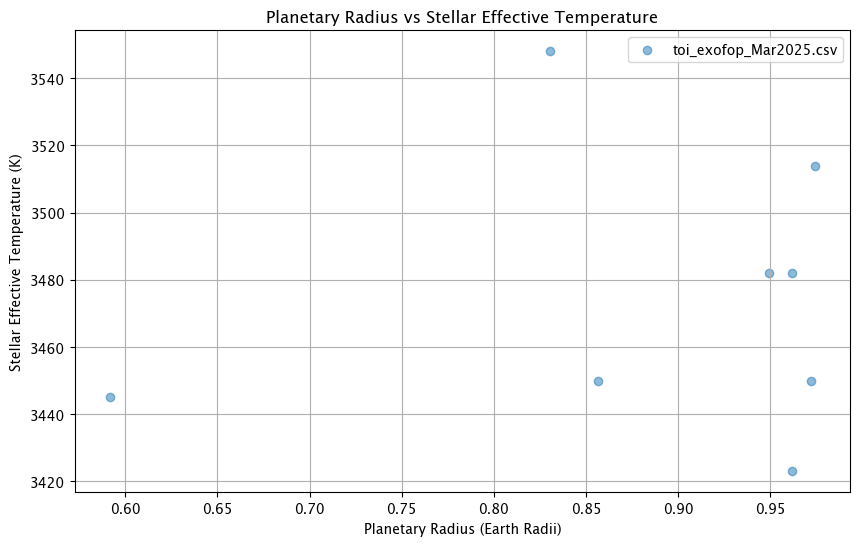

KeyError: 'pl_name'


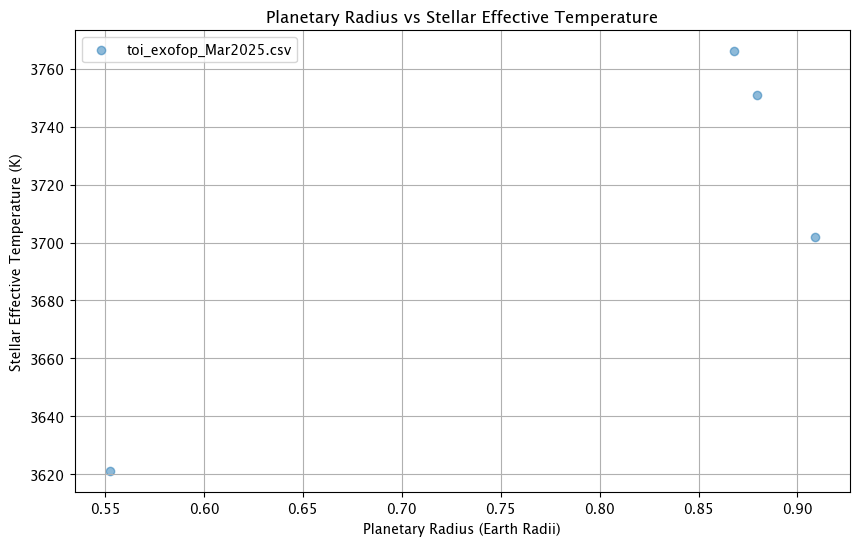

File 1: toi_exofop_Mar2025.csv
8 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
4 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.625, P-value: 0.22222222222222232
KS Statistic for 'st_teff': 1.0, P-value: 0.004040404040404066


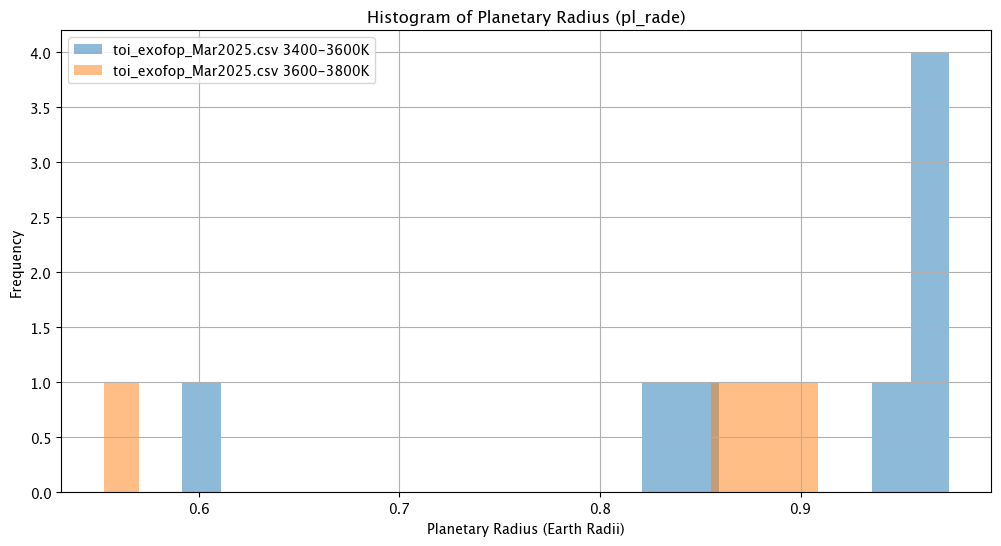

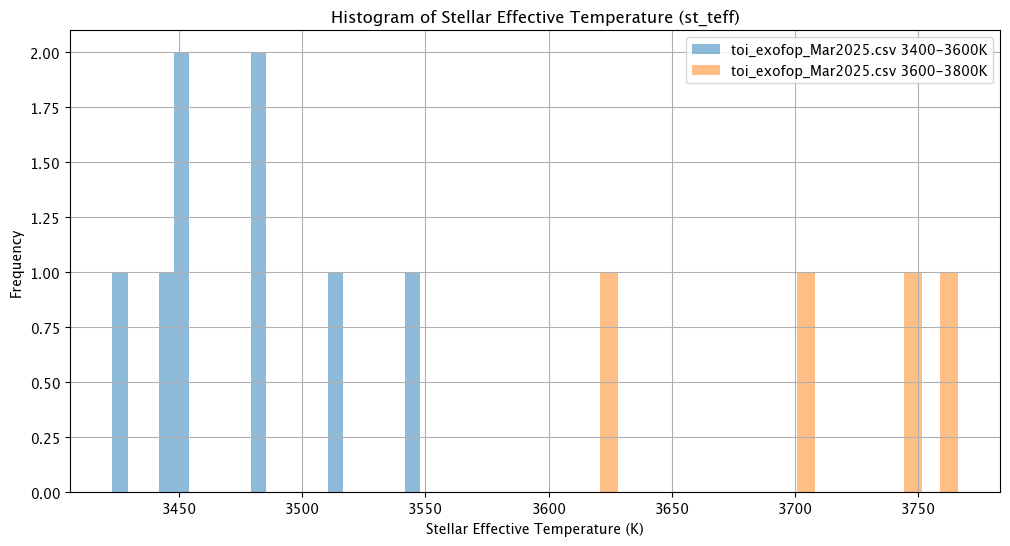

KeyError: 'pl_name'


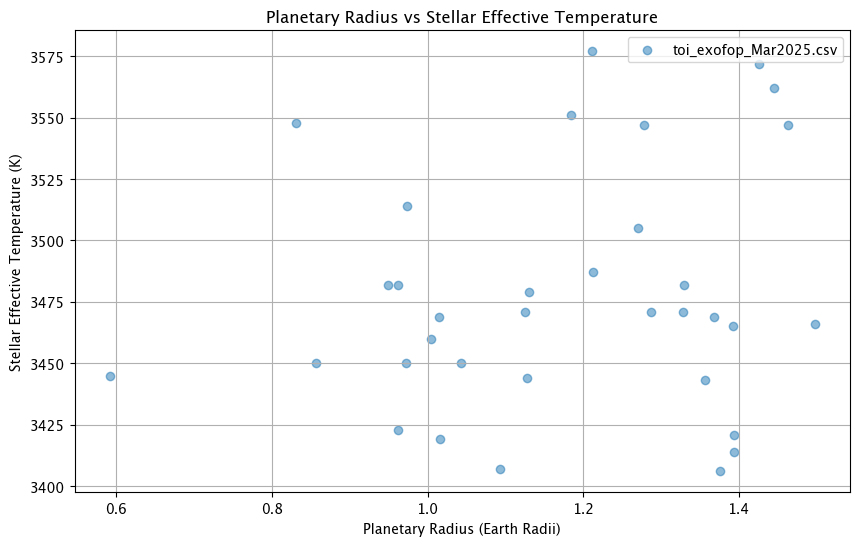

KeyError: 'pl_name'


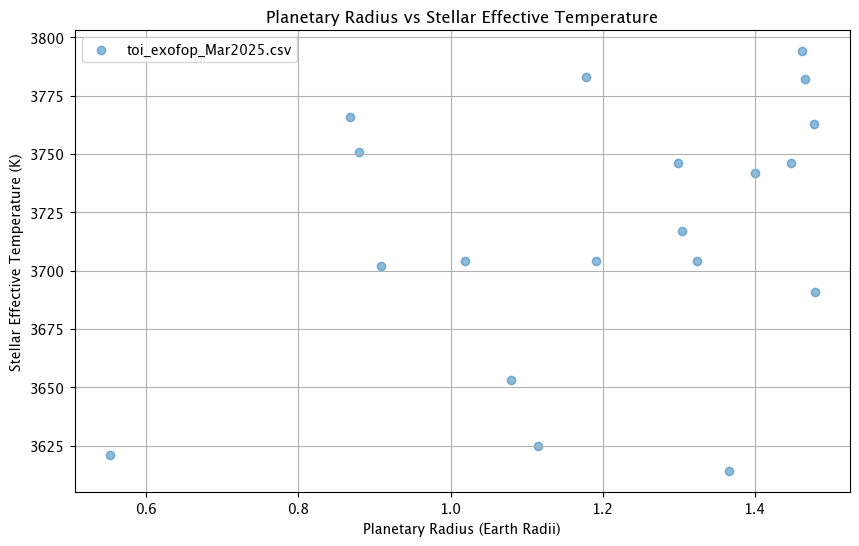

File 1: toi_exofop_Mar2025.csv
34 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
19 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2043343653250774, P-value: 0.6025924946172121
KS Statistic for 'st_teff': 1.0, P-value: 1.6764367671839864e-14


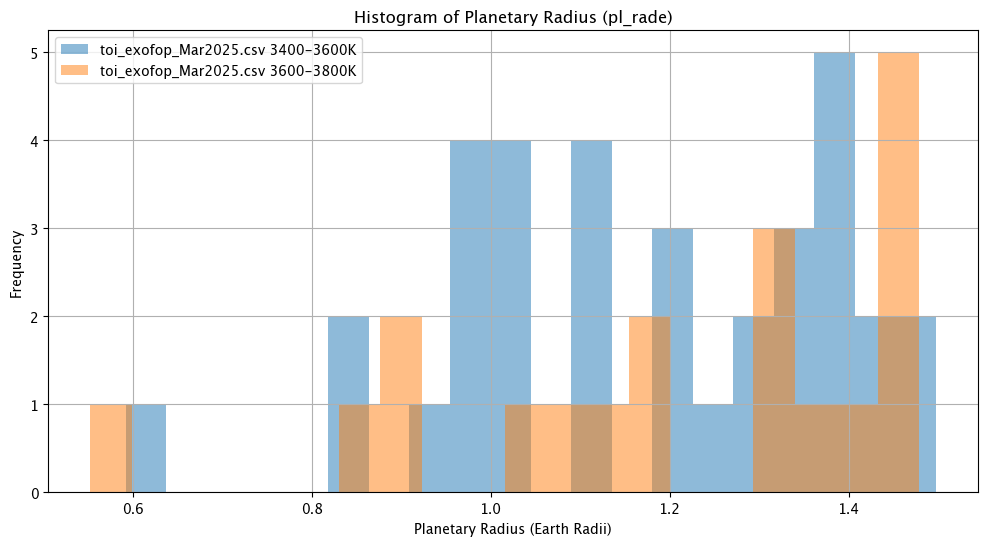

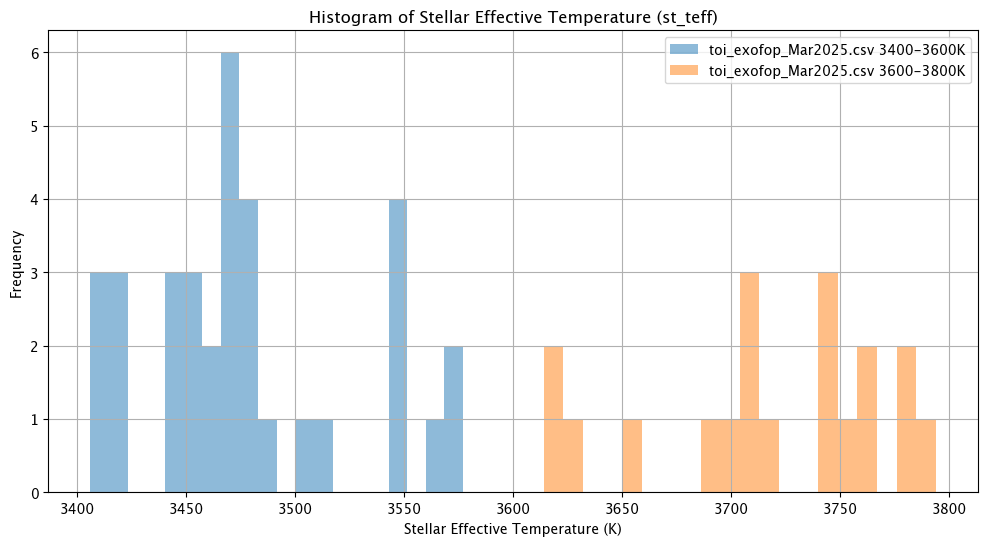

KeyError: 'pl_name'


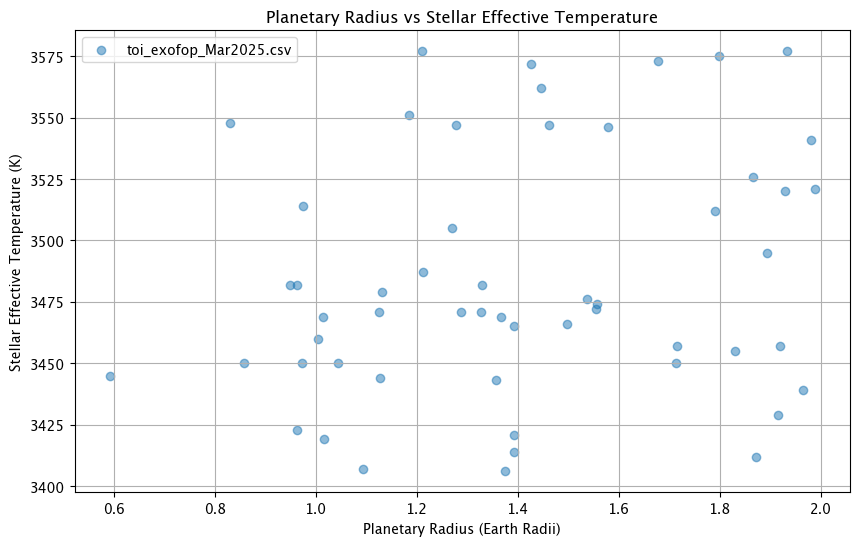

KeyError: 'pl_name'


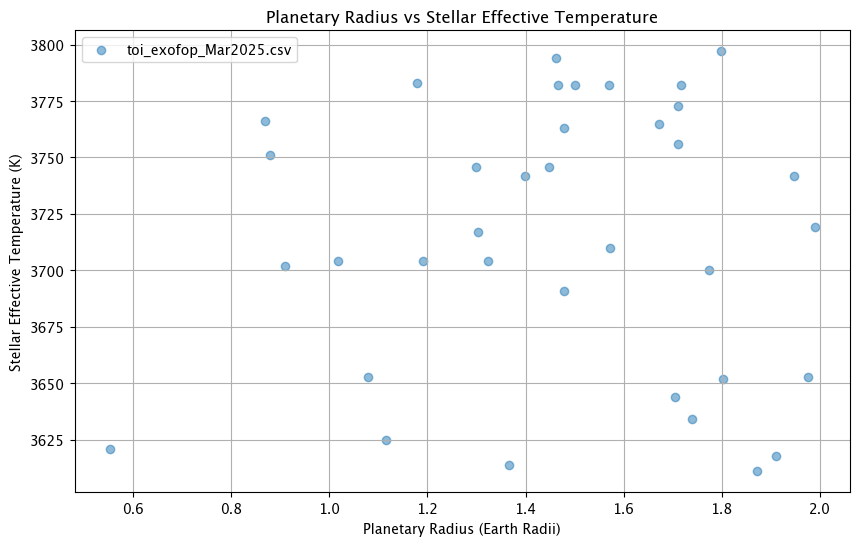

File 1: toi_exofop_Mar2025.csv
54 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
36 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2037037037037037, P-value: 0.30392885132638015
KS Statistic for 'st_teff': 1.0, P-value: 1.1102230246251565e-16


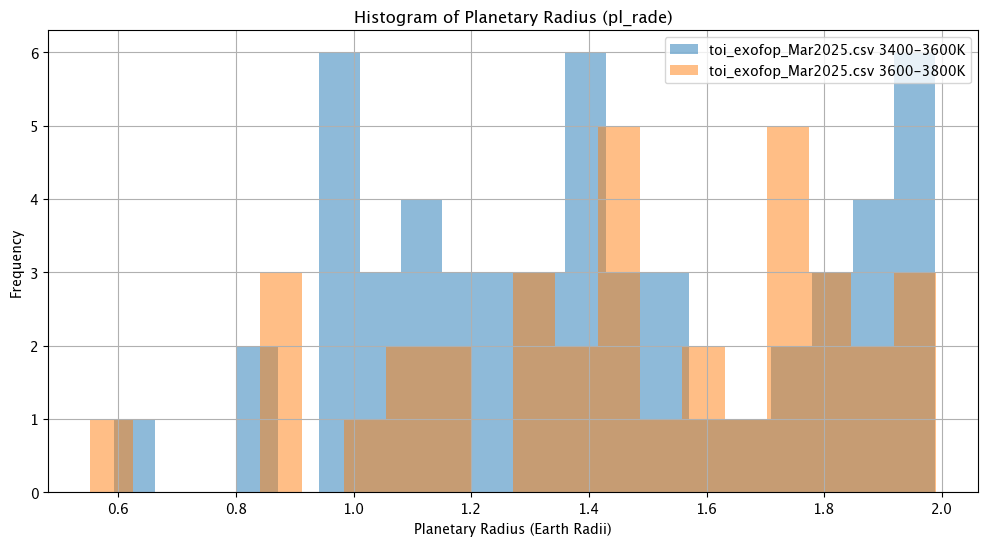

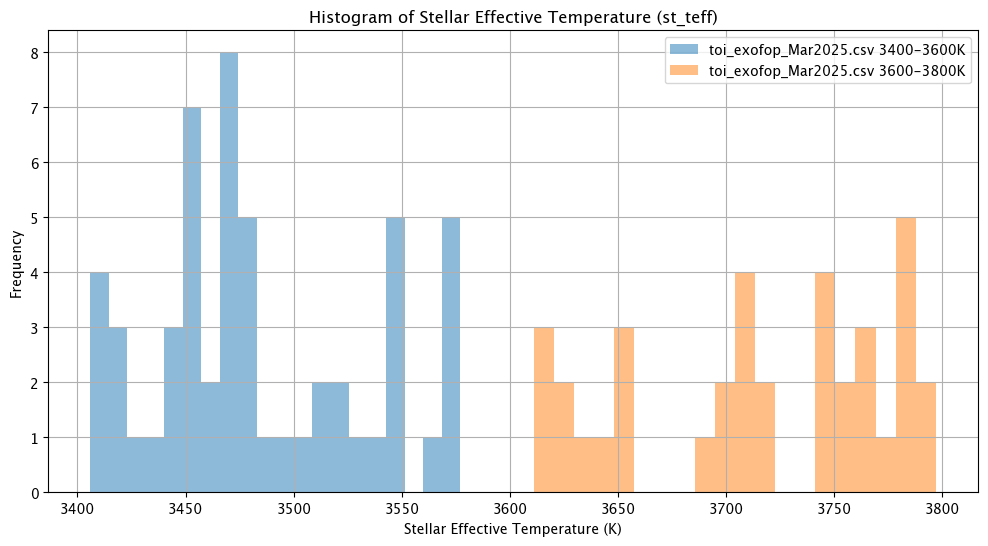

KeyError: 'pl_name'


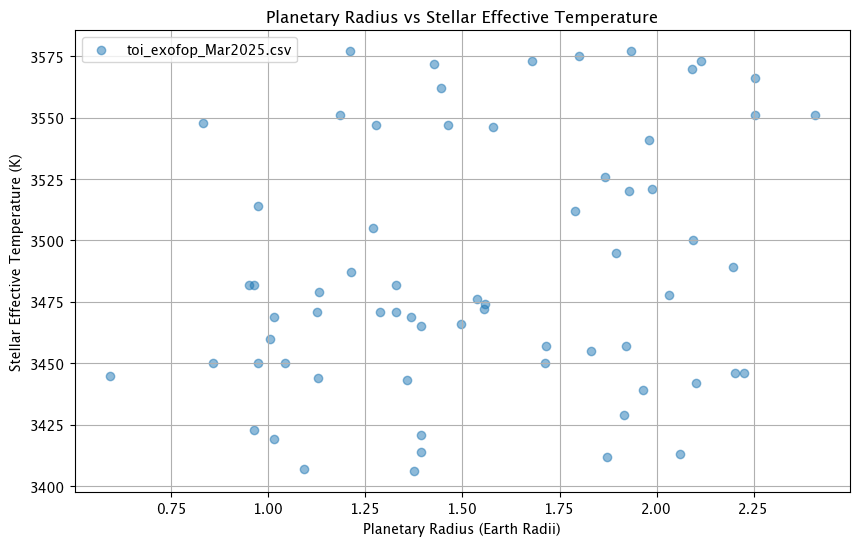

KeyError: 'pl_name'


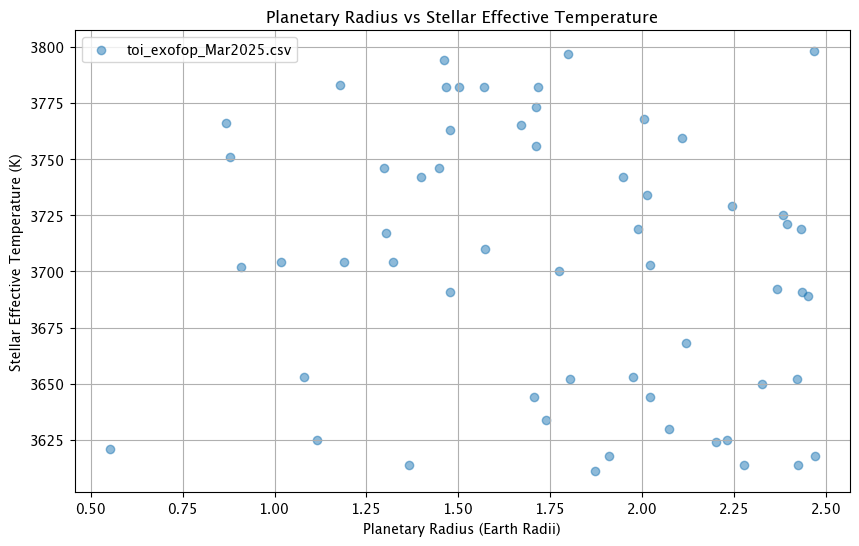

File 1: toi_exofop_Mar2025.csv
66 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
58 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.24346917450365727, P-value: 0.04133365780480236
KS Statistic for 'st_teff': 1.0, P-value: 0.0


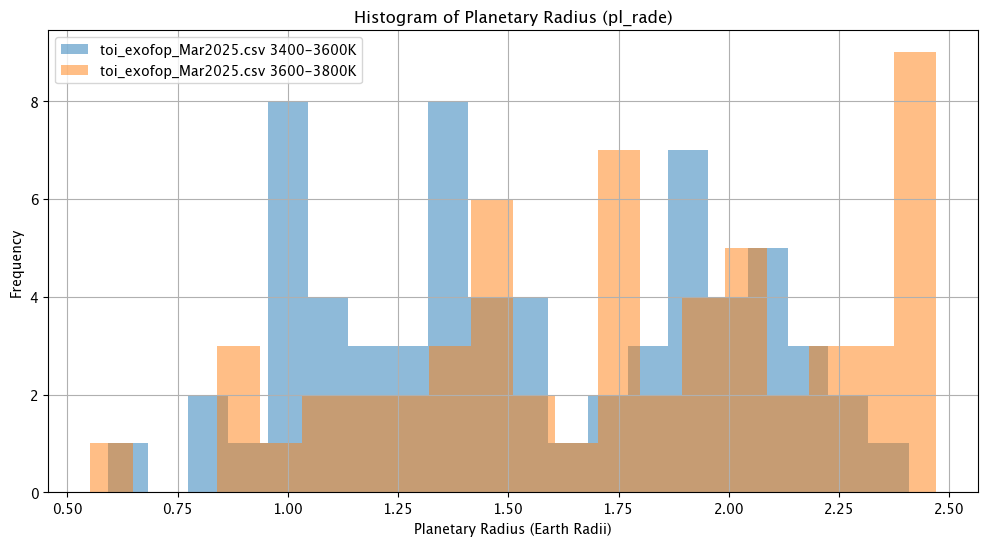

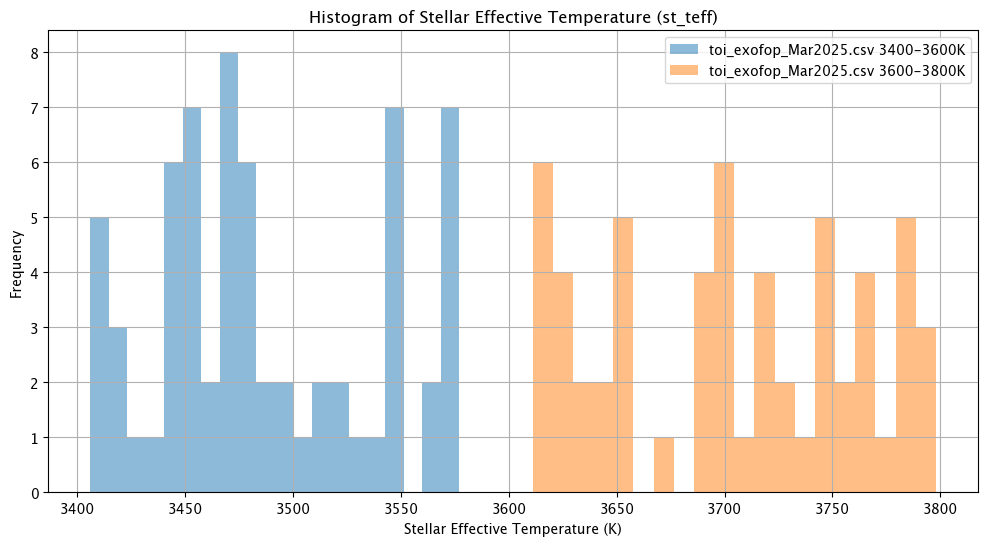

KeyError: 'pl_name'


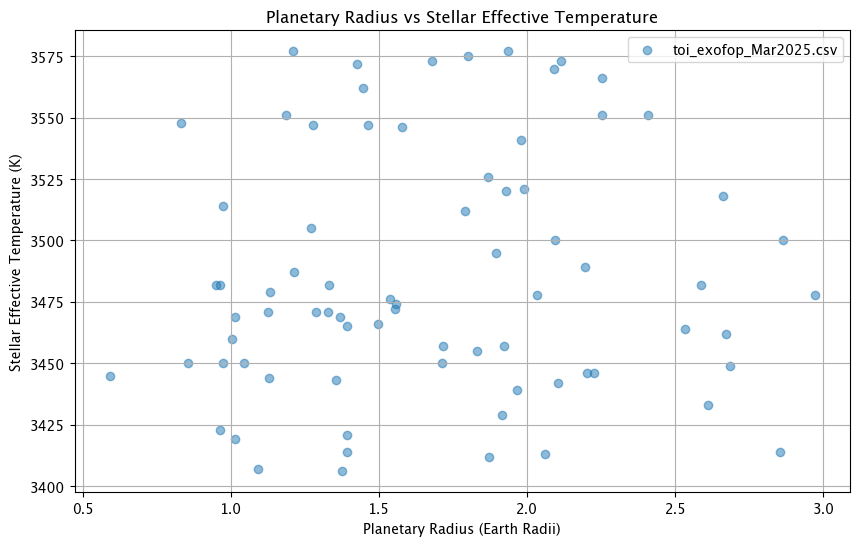

KeyError: 'pl_name'


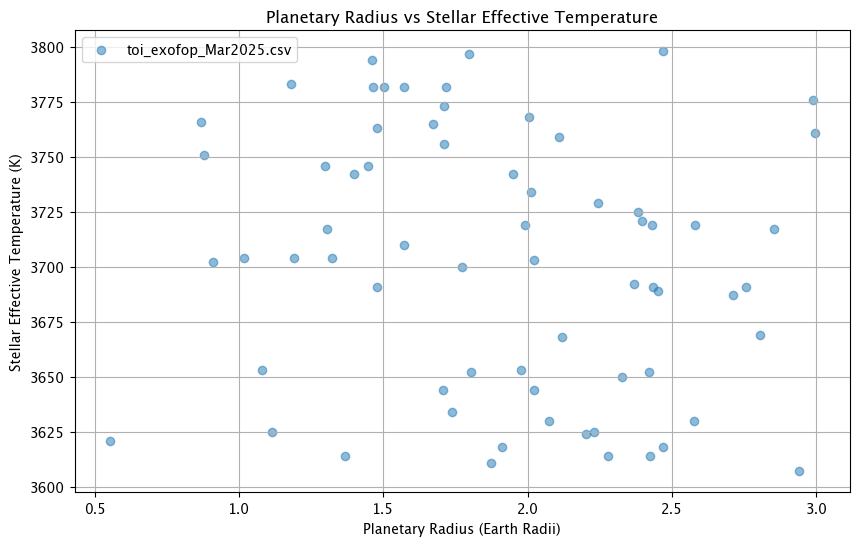

File 1: toi_exofop_Mar2025.csv
75 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
67 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.21771144278606966, P-value: 0.057490280094616764
KS Statistic for 'st_teff': 1.0, P-value: 0.0


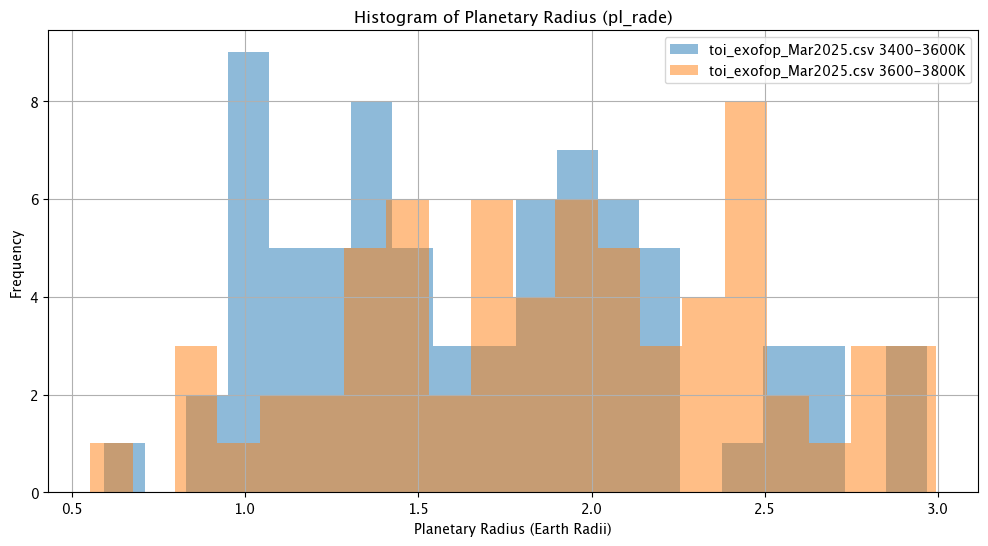

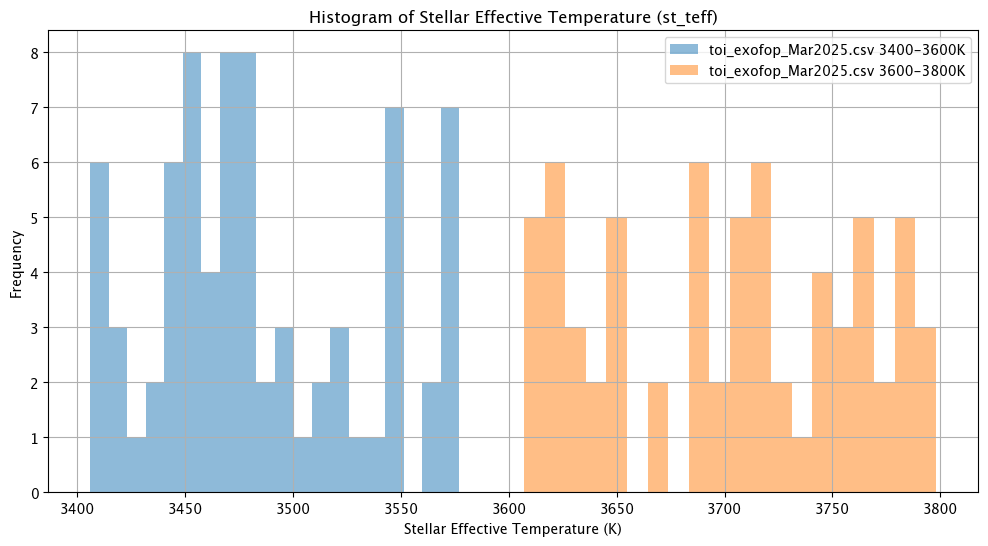

KeyError: 'pl_name'


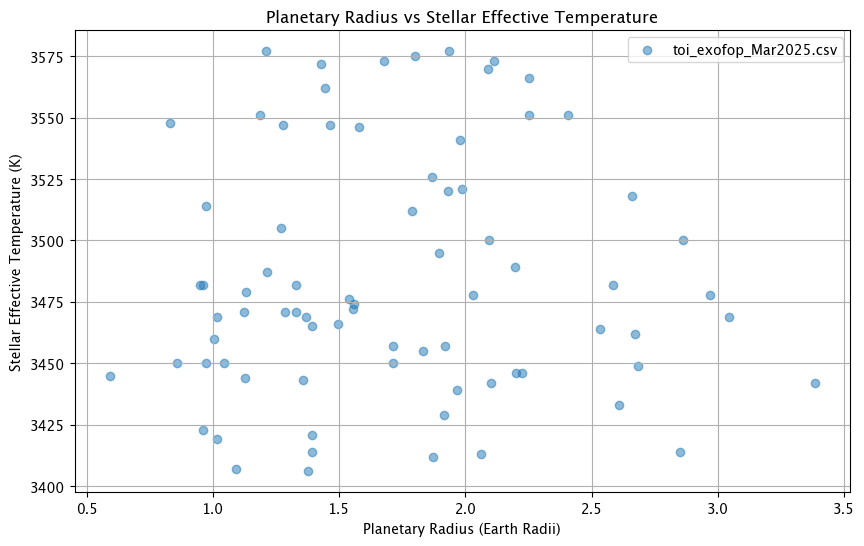

KeyError: 'pl_name'


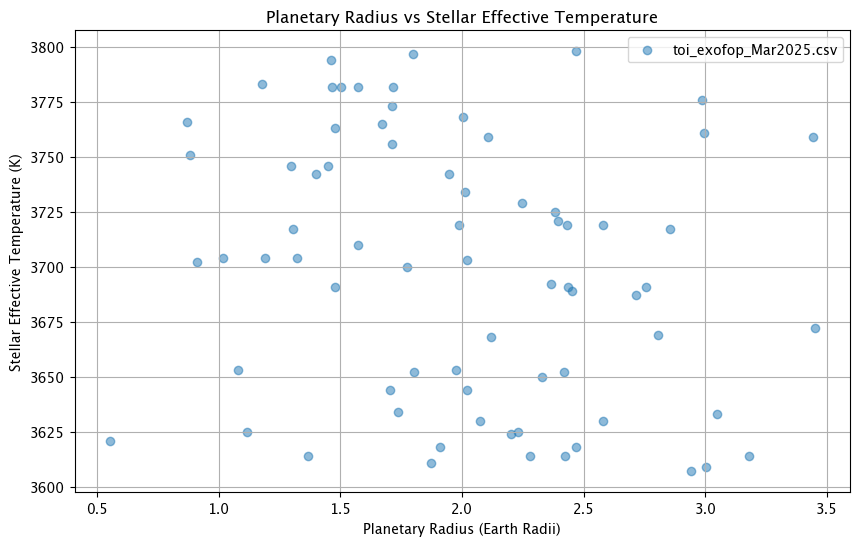

File 1: toi_exofop_Mar2025.csv
77 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
72 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.22113997113997114, P-value: 0.04272672524330645
KS Statistic for 'st_teff': 1.0, P-value: 2.220446049250313e-16


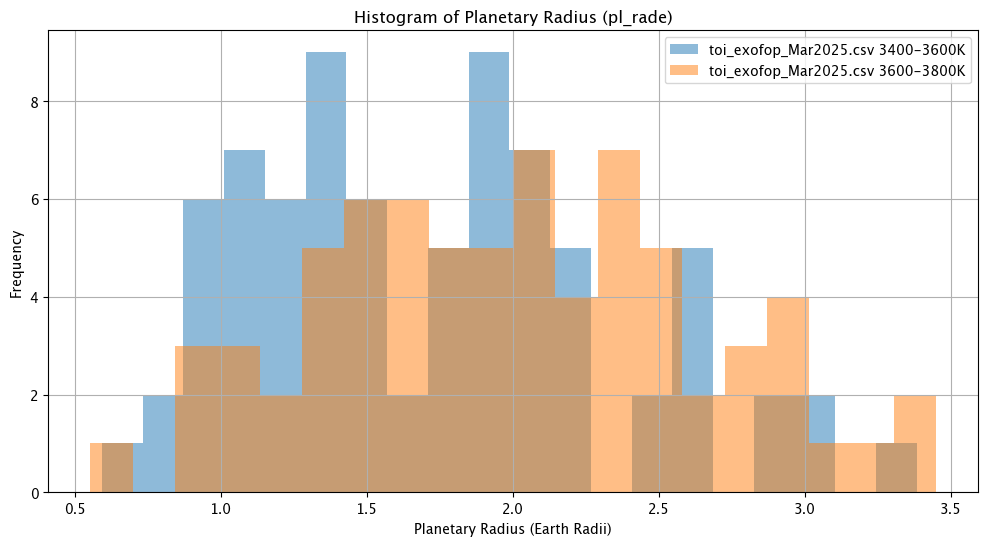

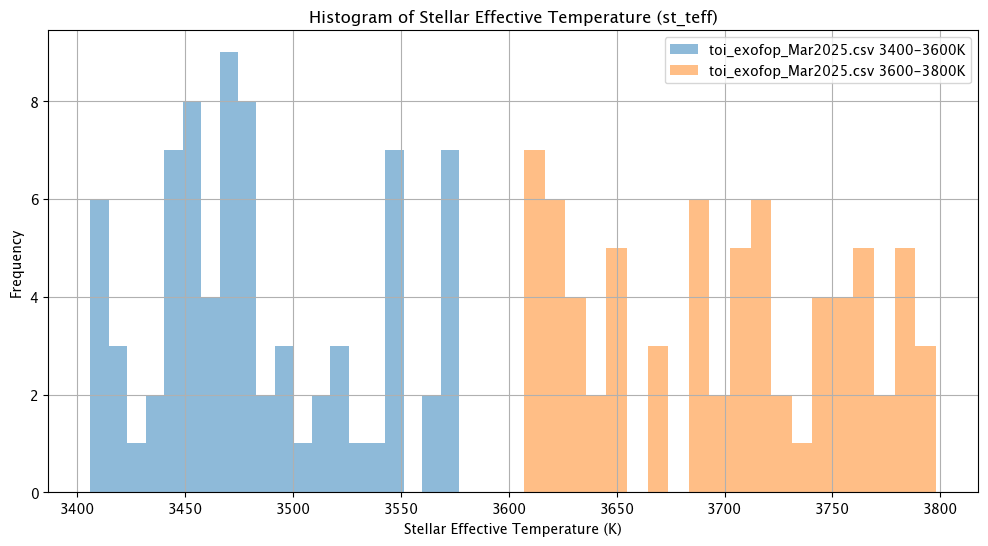

KeyError: 'pl_name'


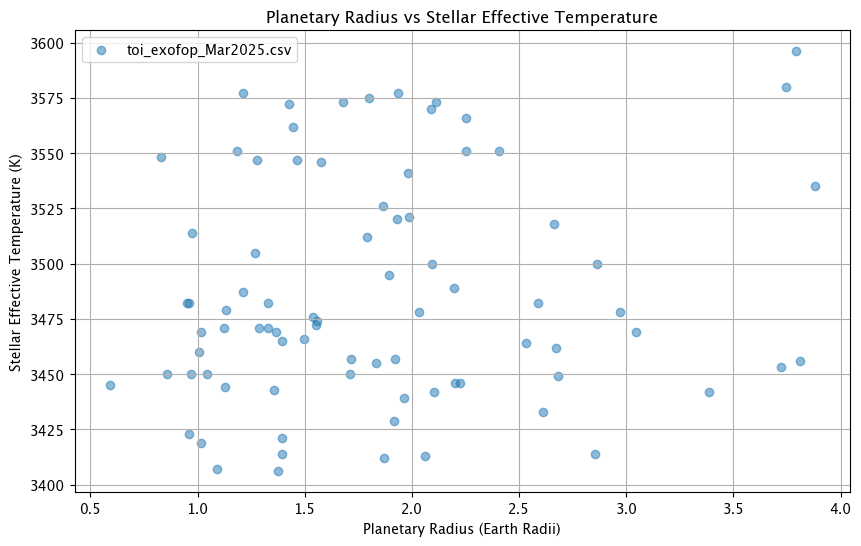

KeyError: 'pl_name'


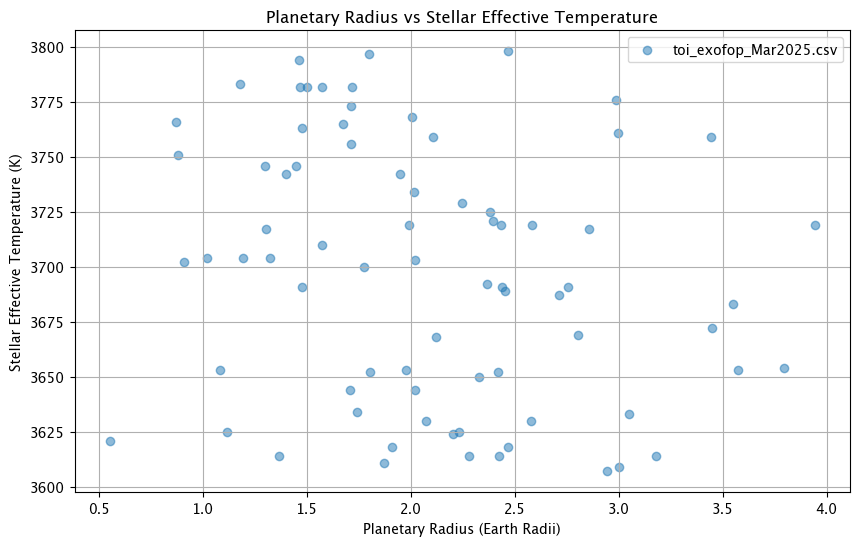

File 1: toi_exofop_Mar2025.csv
82 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
76 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.2060333761232349, P-value: 0.058269935978121135
KS Statistic for 'st_teff': 1.0, P-value: 0.0


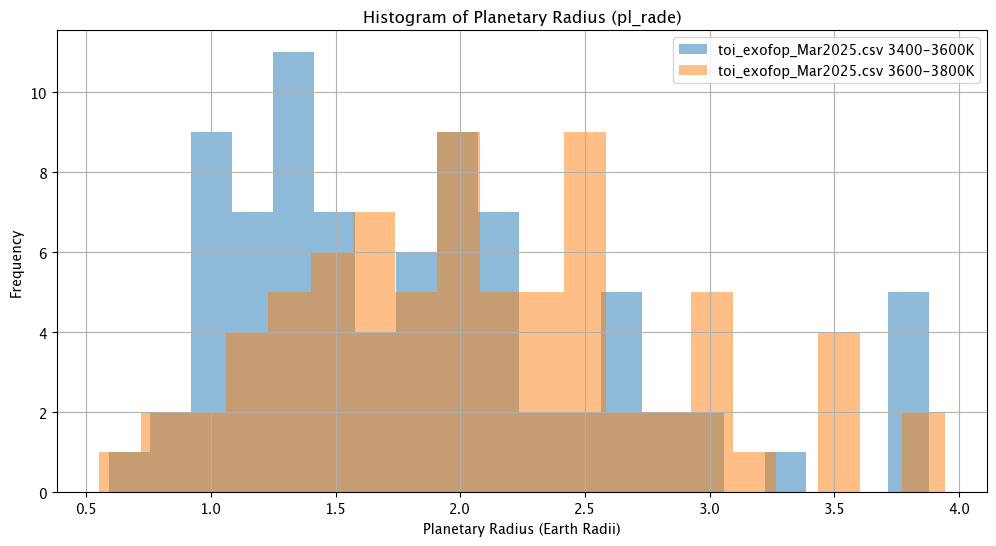

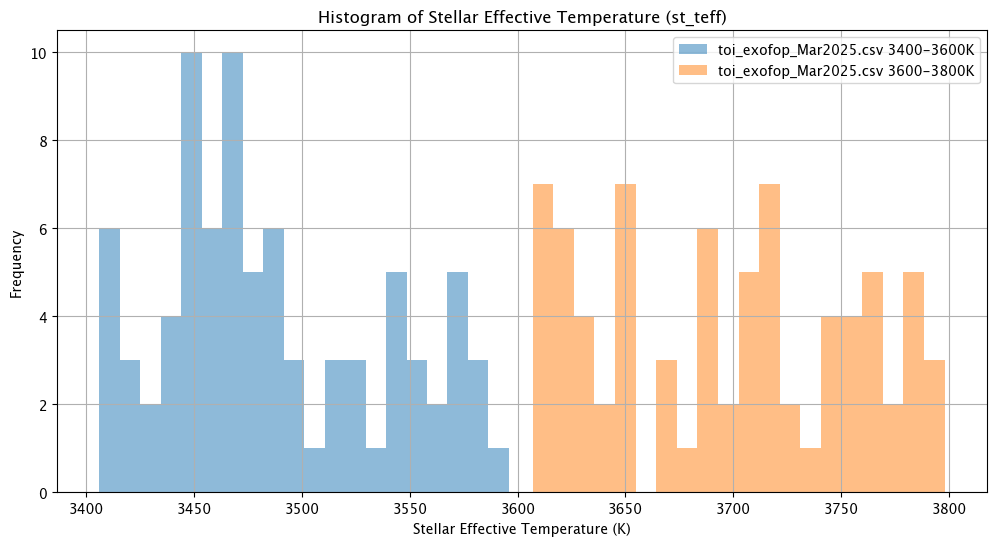

KeyError: 'pl_name'


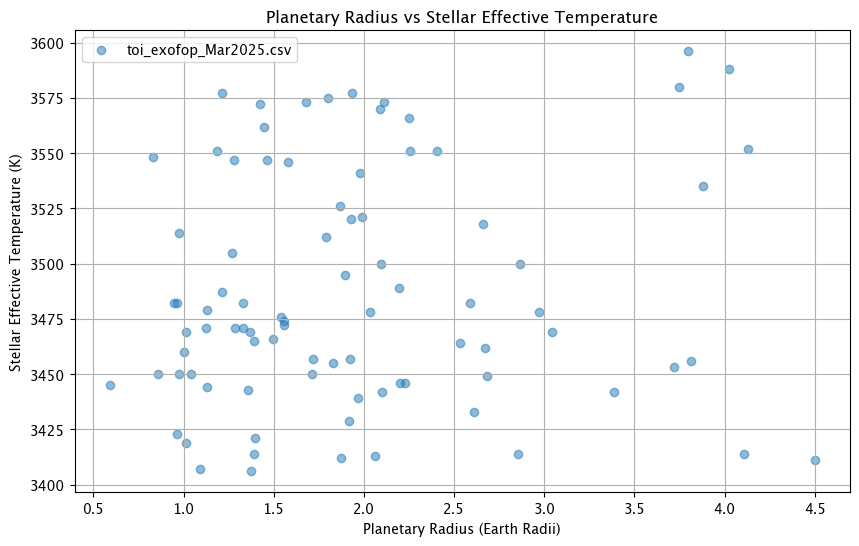

KeyError: 'pl_name'


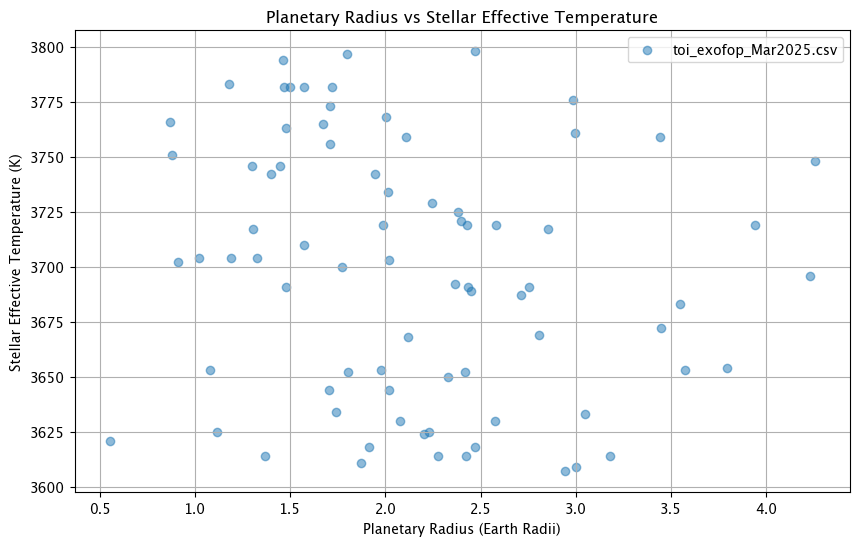

File 1: toi_exofop_Mar2025.csv
86 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
78 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.19260584376863446, P-value: 0.08102115903639218
KS Statistic for 'st_teff': 1.0, P-value: 0.0


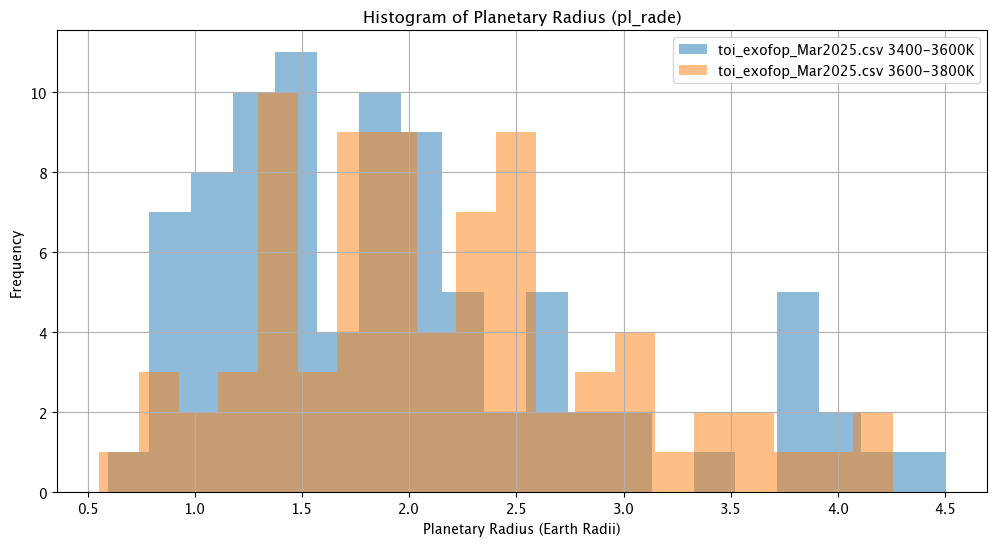

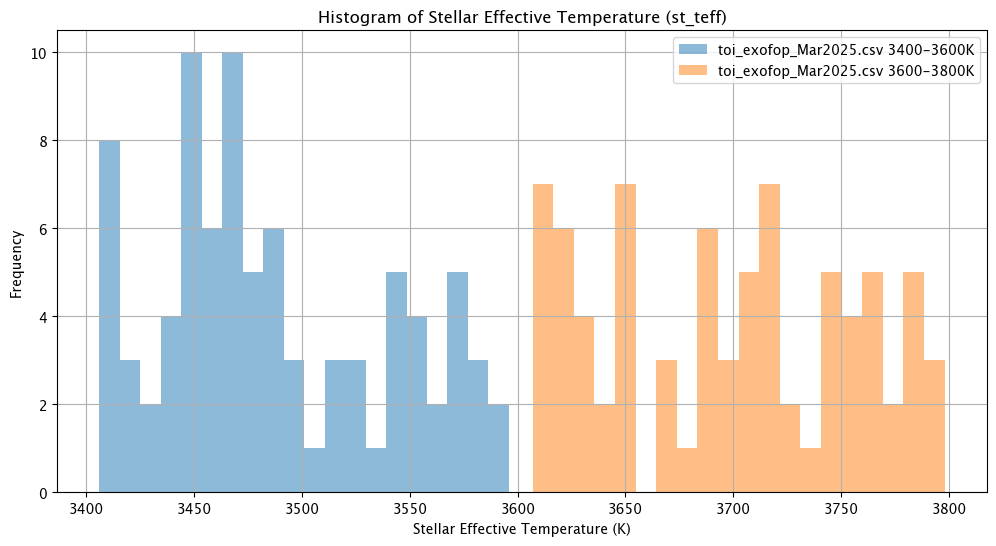

KeyError: 'pl_name'


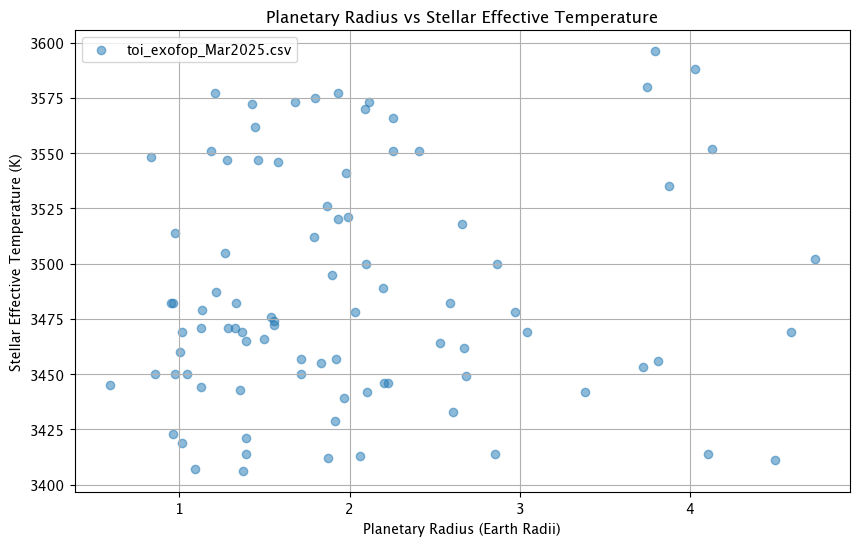

KeyError: 'pl_name'


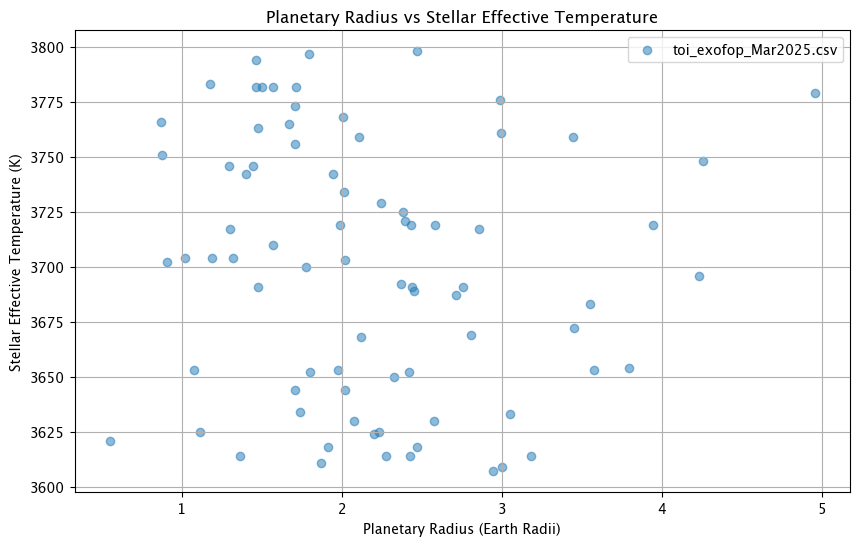

File 1: toi_exofop_Mar2025.csv
88 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
79 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.18642117376294592, P-value: 0.09386655161816992
KS Statistic for 'st_teff': 1.0, P-value: 0.0


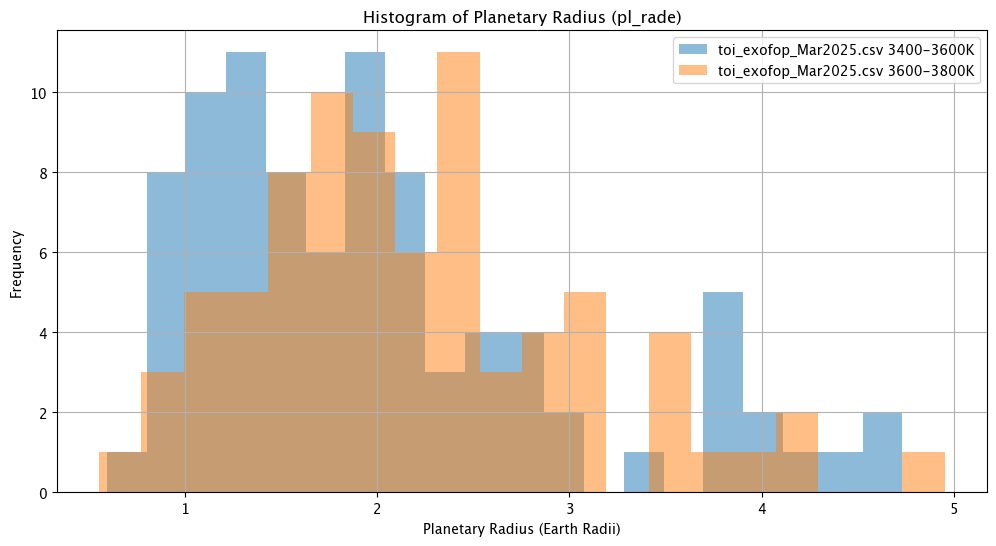

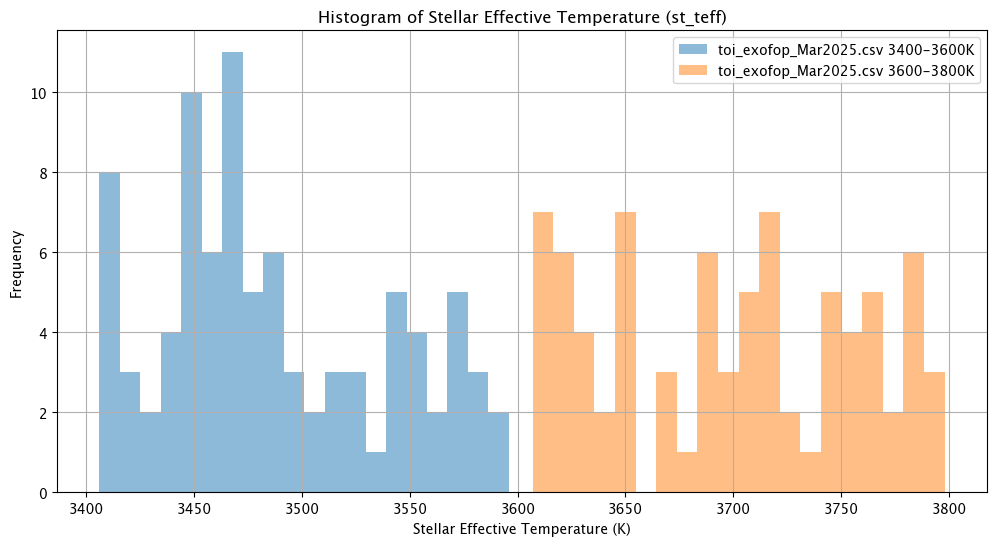

KeyError: 'pl_name'


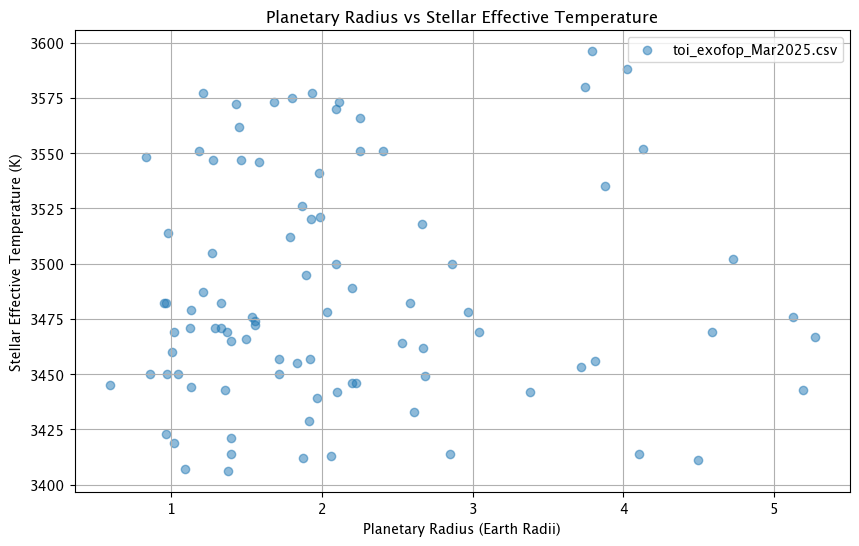

KeyError: 'pl_name'


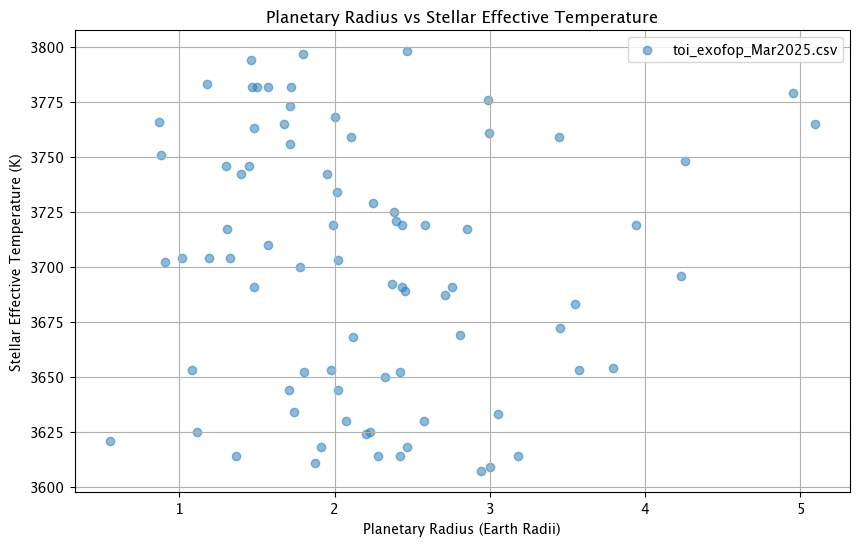

File 1: toi_exofop_Mar2025.csv
91 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
80 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.17664835164835166, P-value: 0.12031475605893538
KS Statistic for 'st_teff': 1.0, P-value: 1.1102230246251565e-16


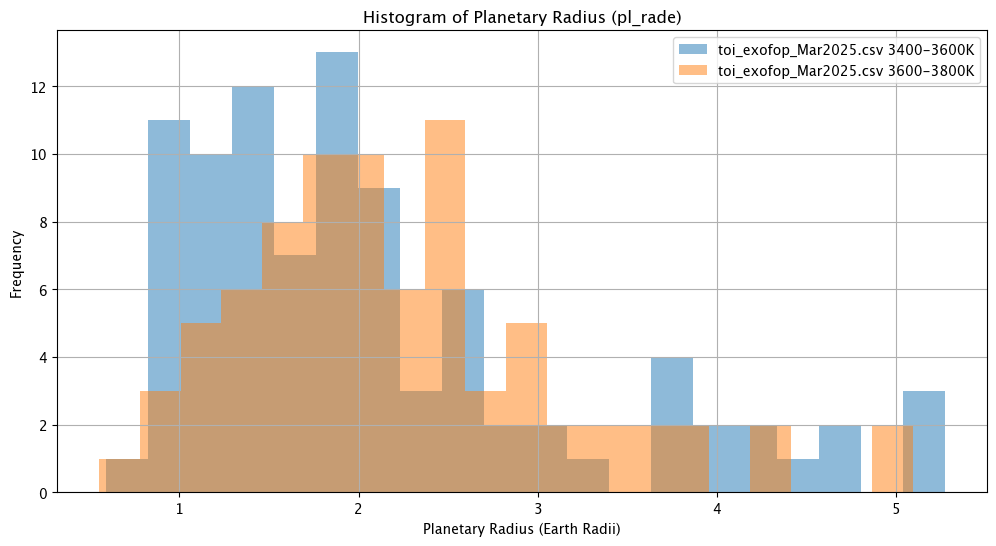

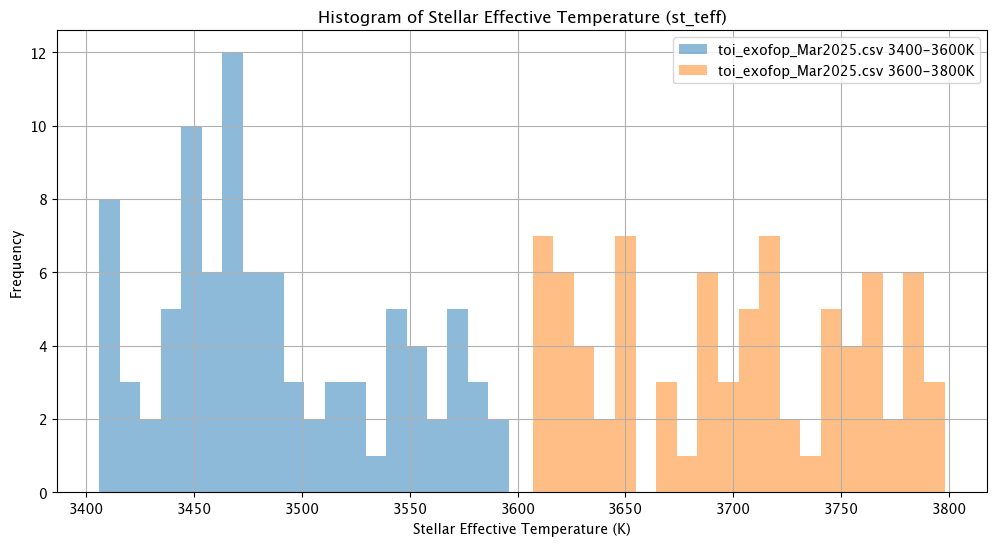

KeyError: 'pl_name'


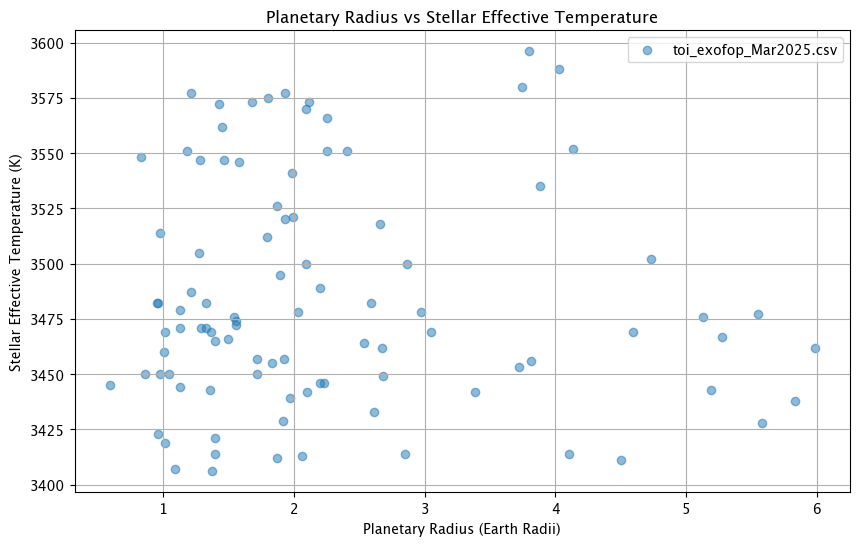

KeyError: 'pl_name'


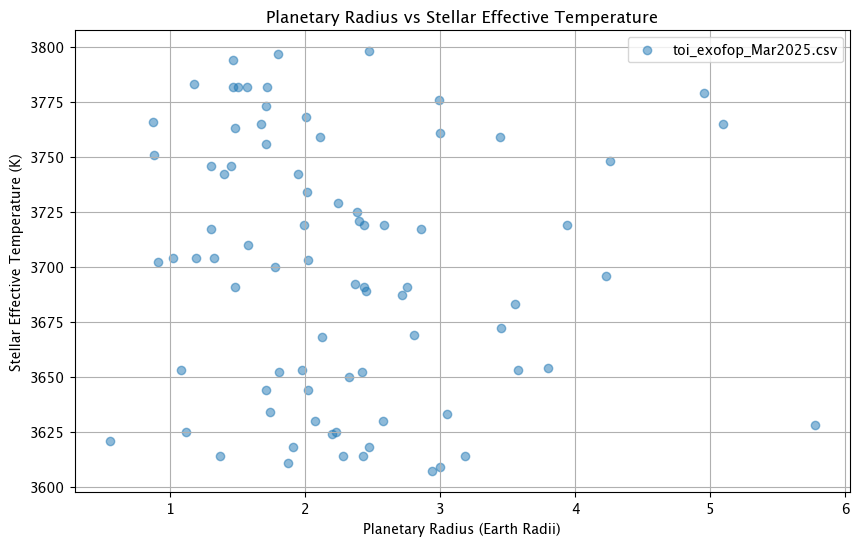

File 1: toi_exofop_Mar2025.csv
95 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
81 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.1640025990903184, P-value: 0.1649059400110393
KS Statistic for 'st_teff': 1.0, P-value: 3.3306690738754696e-16


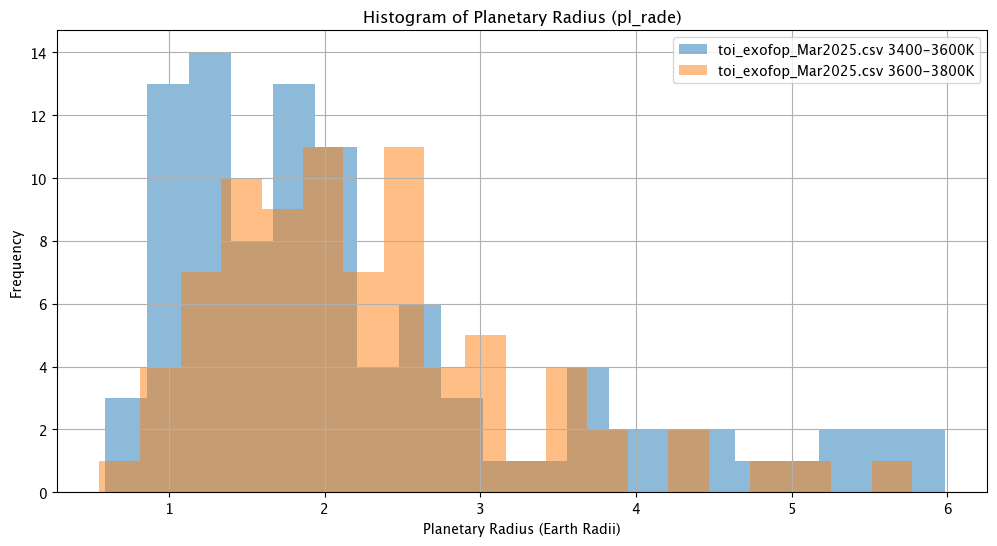

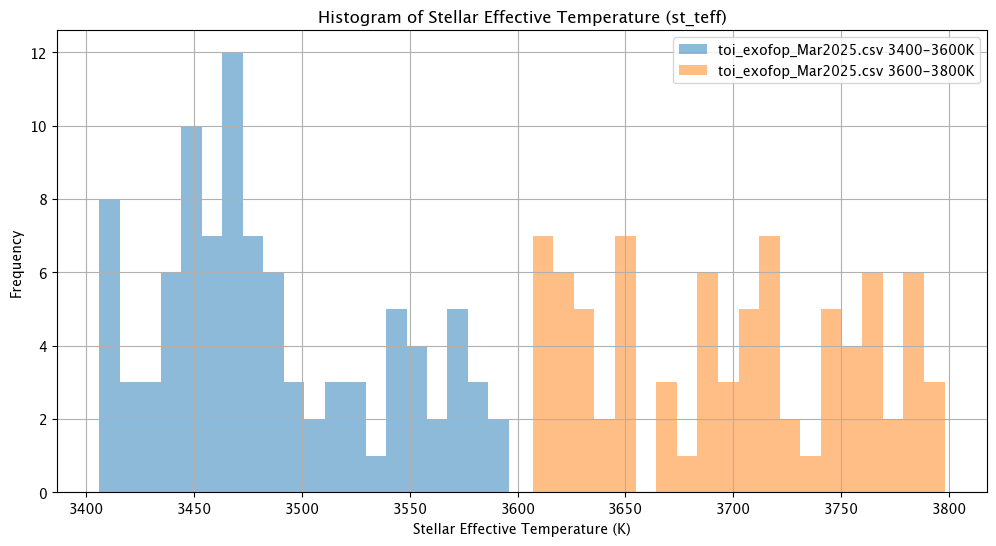

KeyError: 'pl_name'


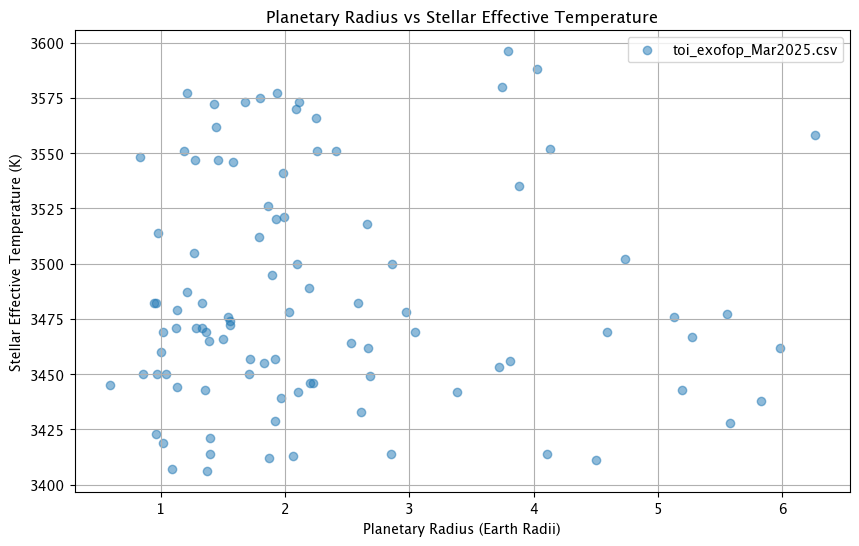

KeyError: 'pl_name'


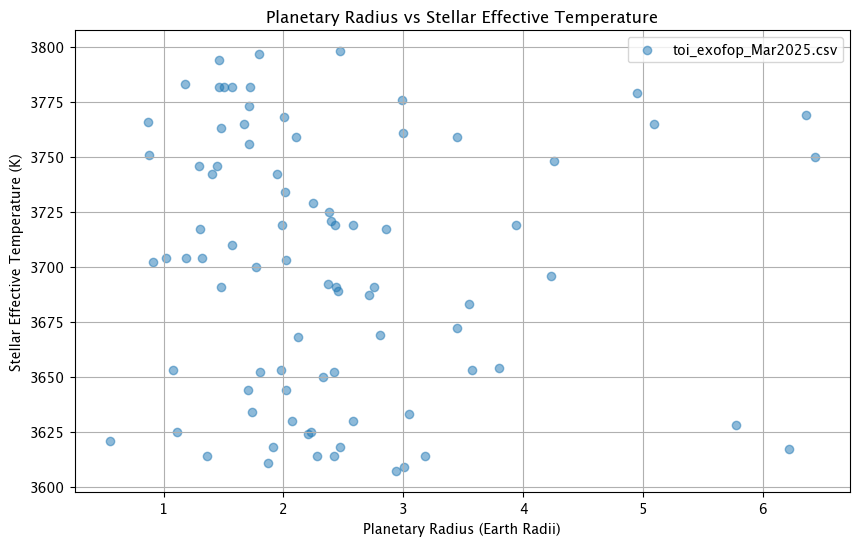

File 1: toi_exofop_Mar2025.csv
96 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
84 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.16666666666666666, P-value: 0.14640402014473342
KS Statistic for 'st_teff': 1.0, P-value: 3.3306690738754696e-16


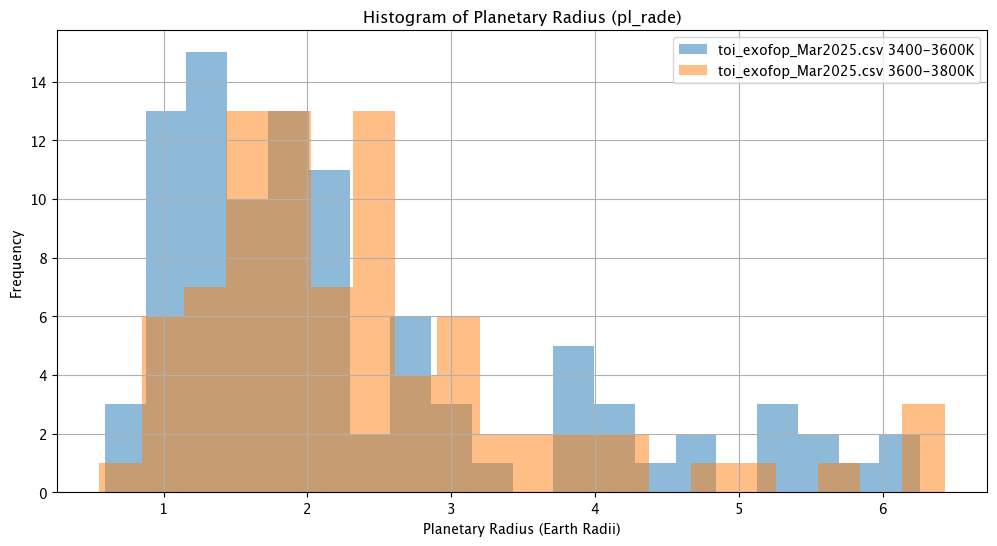

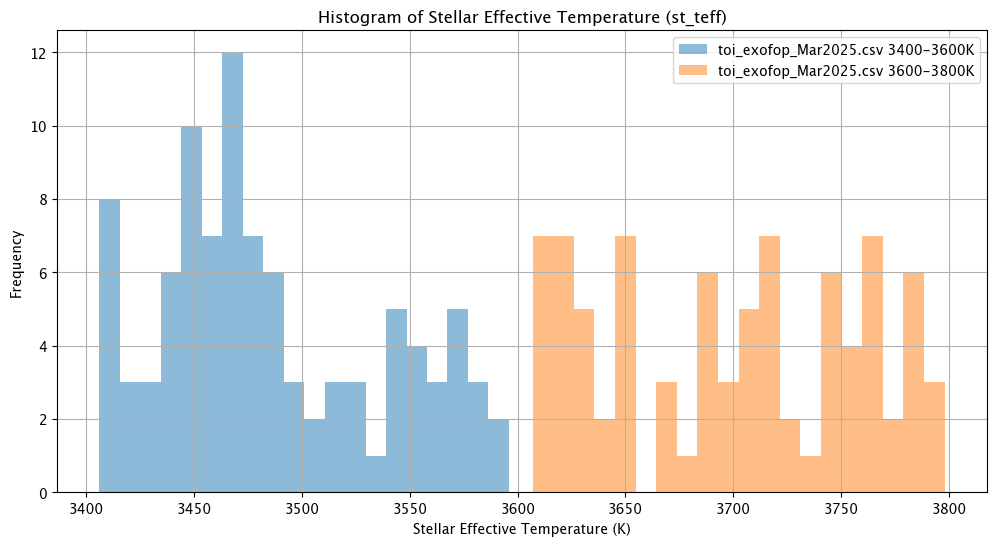

KeyError: 'pl_name'


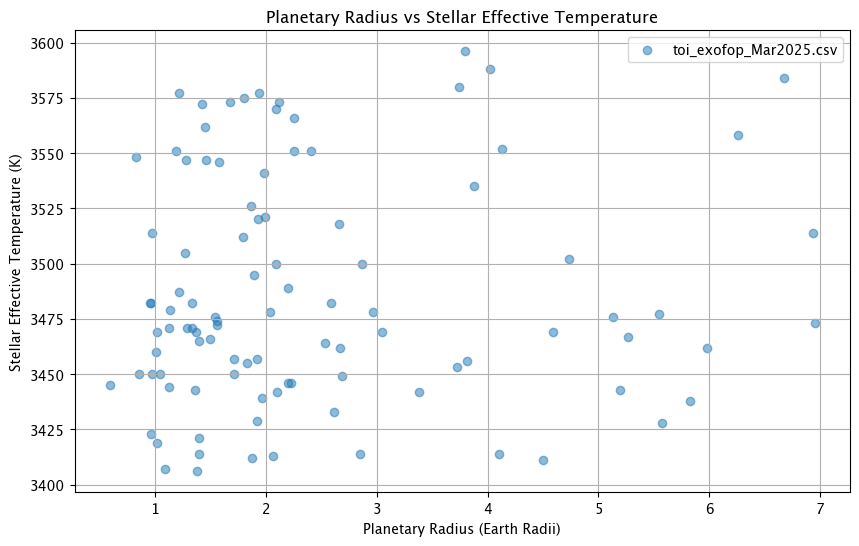

KeyError: 'pl_name'


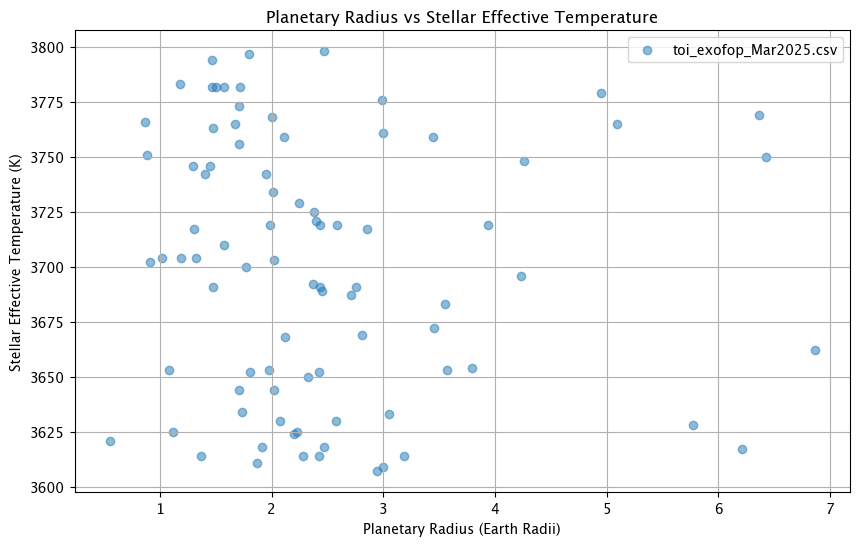

File 1: toi_exofop_Mar2025.csv
99 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
85 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.15852644087938206, P-value: 0.17623604901078405
KS Statistic for 'st_teff': 1.0, P-value: 1.6653345369377348e-15


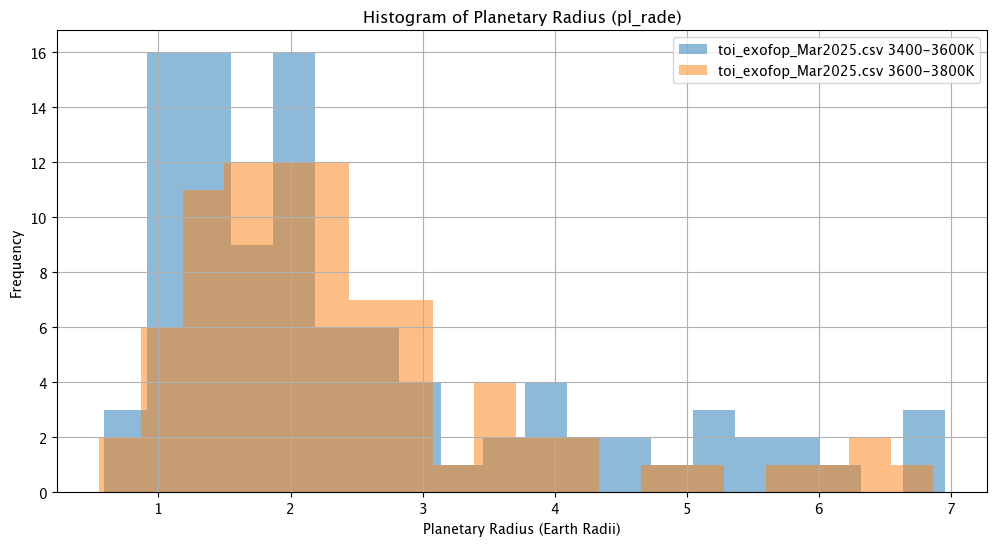

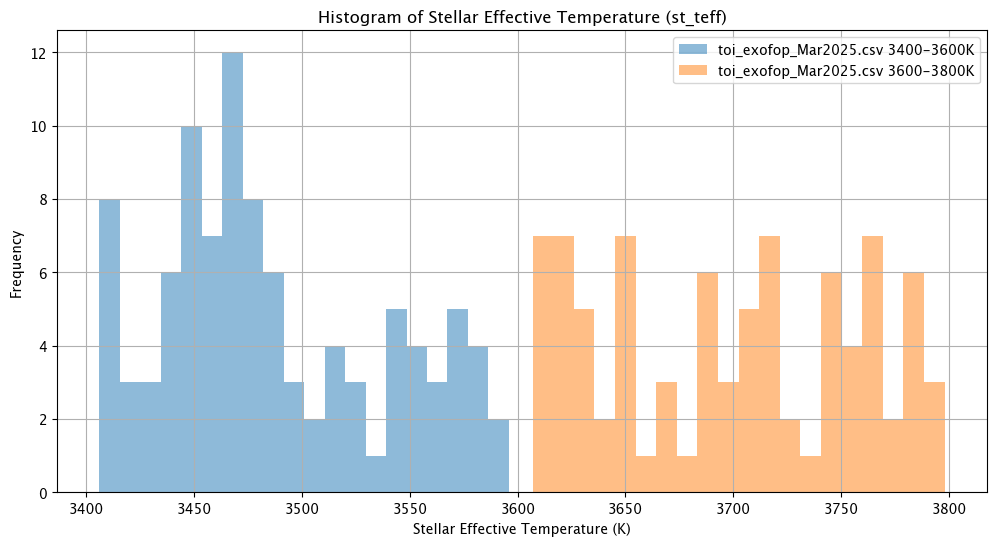

KeyError: 'pl_name'


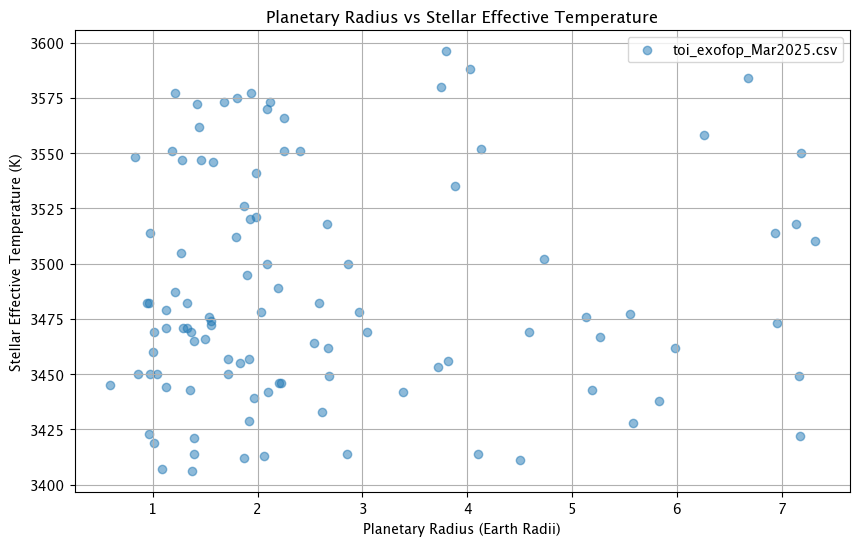

KeyError: 'pl_name'


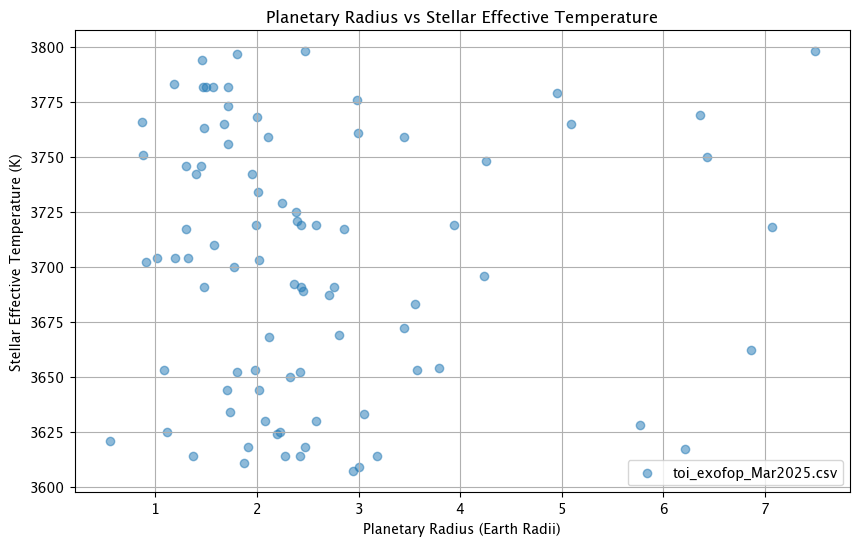

File 1: toi_exofop_Mar2025.csv
104 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
87 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.14677276746242263, P-value: 0.22885256831982193
KS Statistic for 'st_teff': 1.0, P-value: 0.0


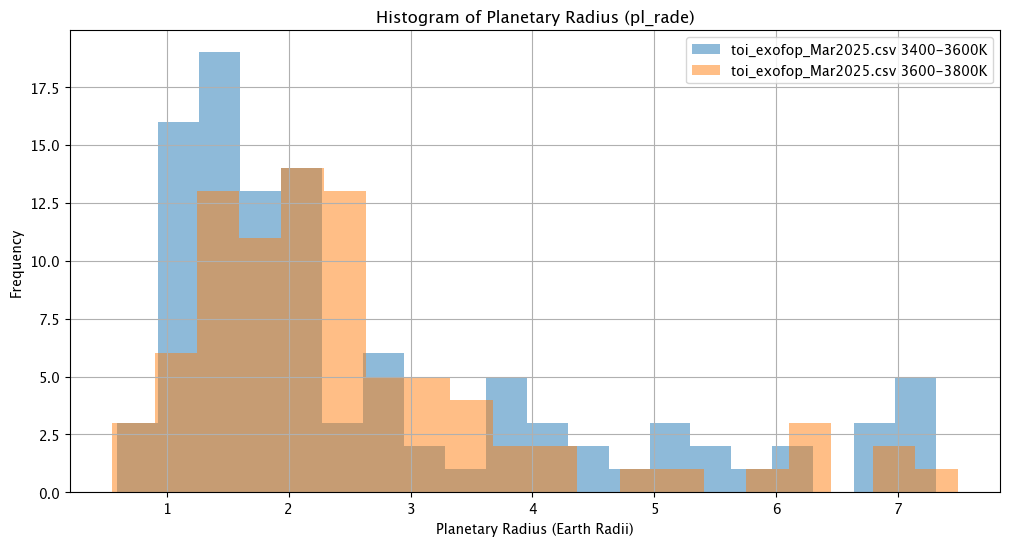

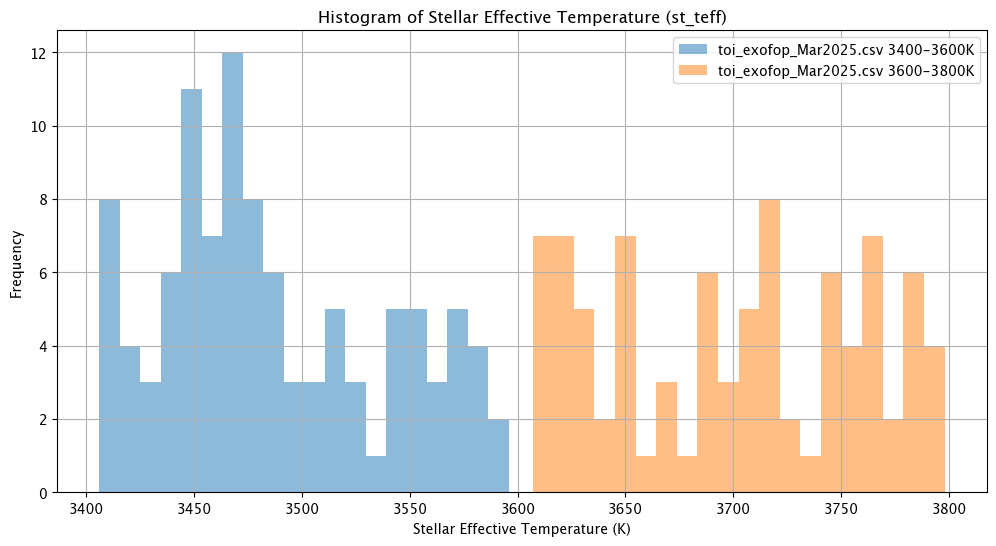

KeyError: 'pl_name'


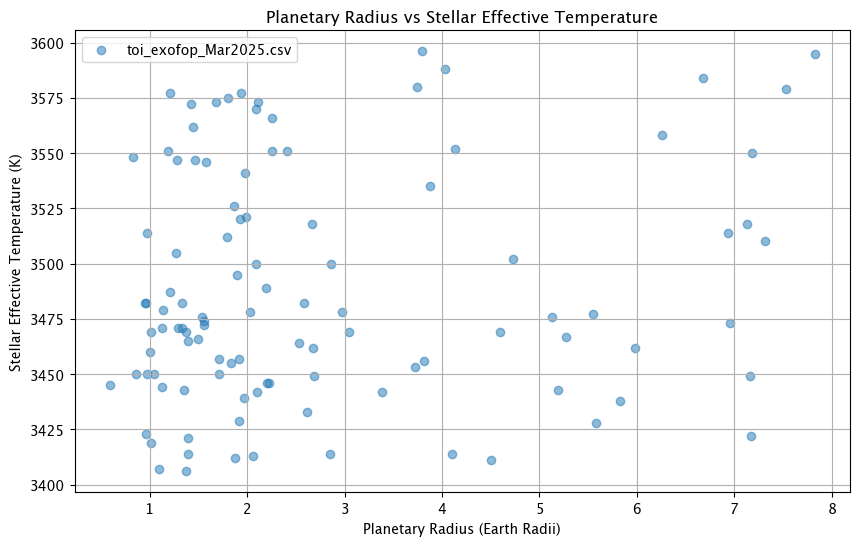

KeyError: 'pl_name'


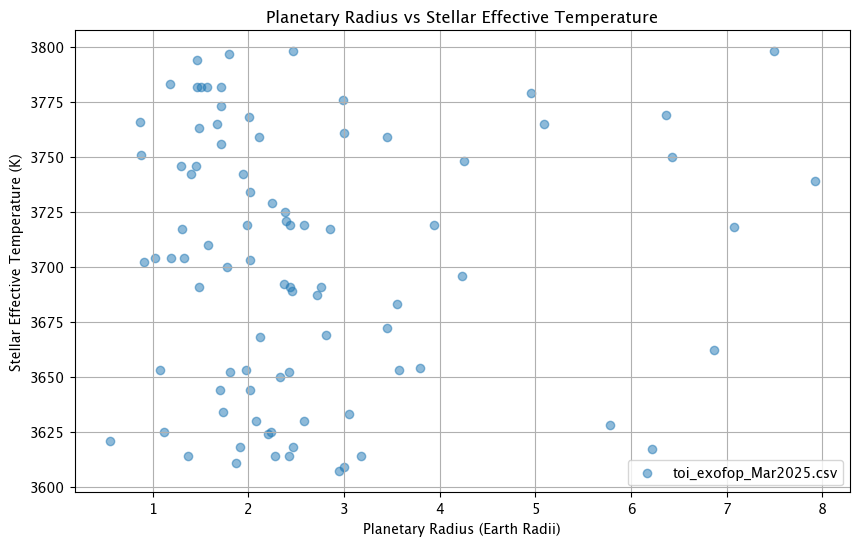

File 1: toi_exofop_Mar2025.csv
106 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
88 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.1427958833619211, P-value: 0.24911087589389402
KS Statistic for 'st_teff': 1.0, P-value: 0.0


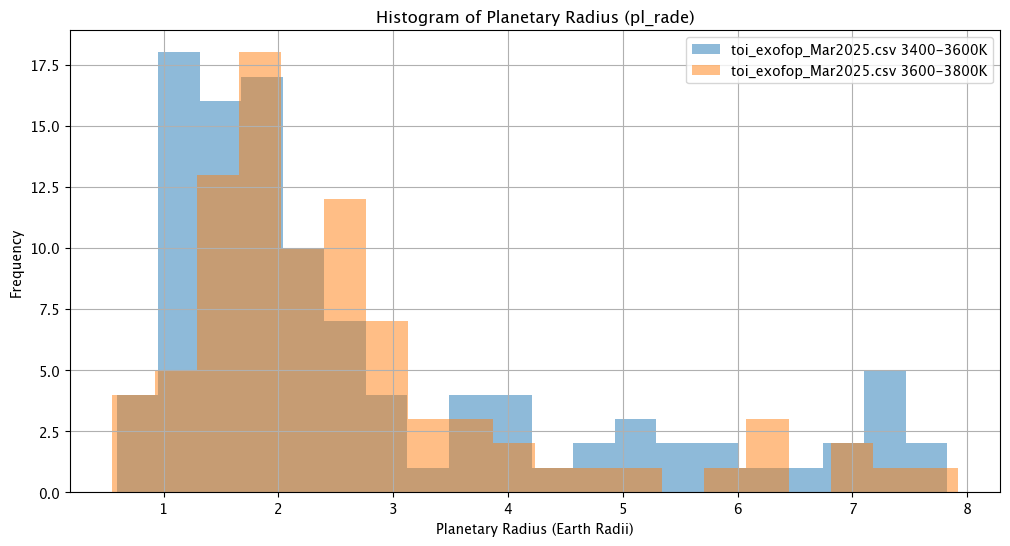

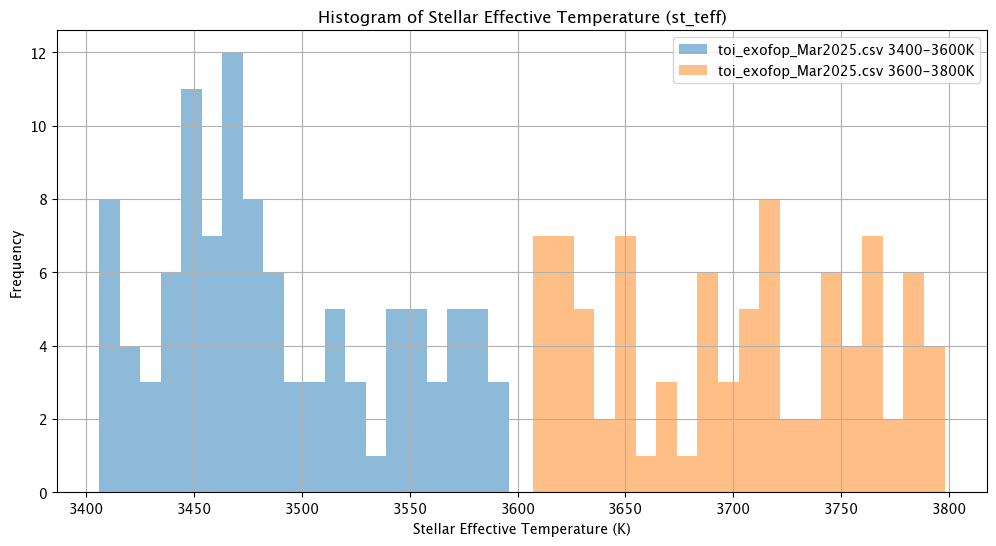

KeyError: 'pl_name'


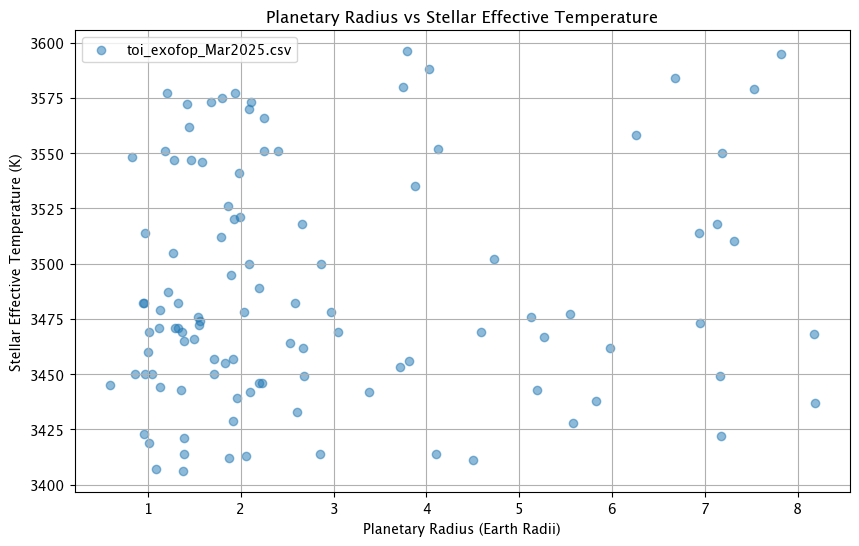

KeyError: 'pl_name'


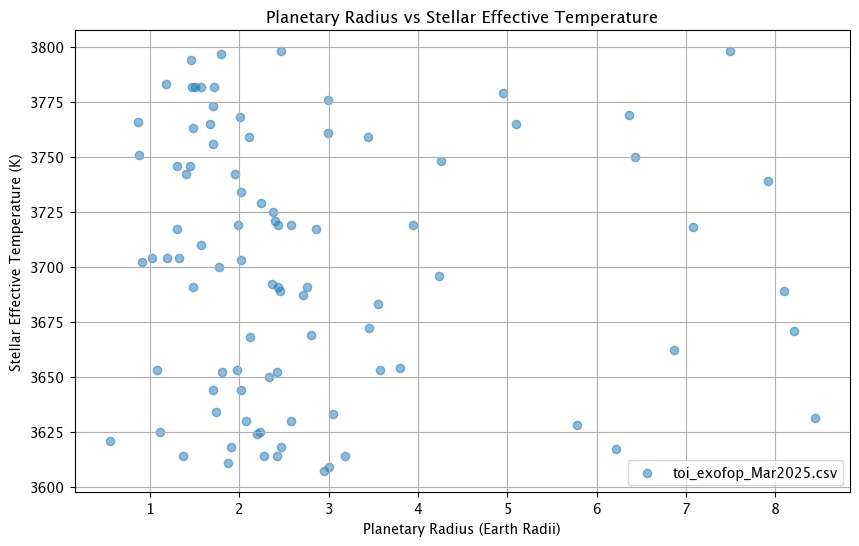

File 1: toi_exofop_Mar2025.csv
108 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
91 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.14245014245014245, P-value: 0.23860220484394645
KS Statistic for 'st_teff': 1.0, P-value: 0.0


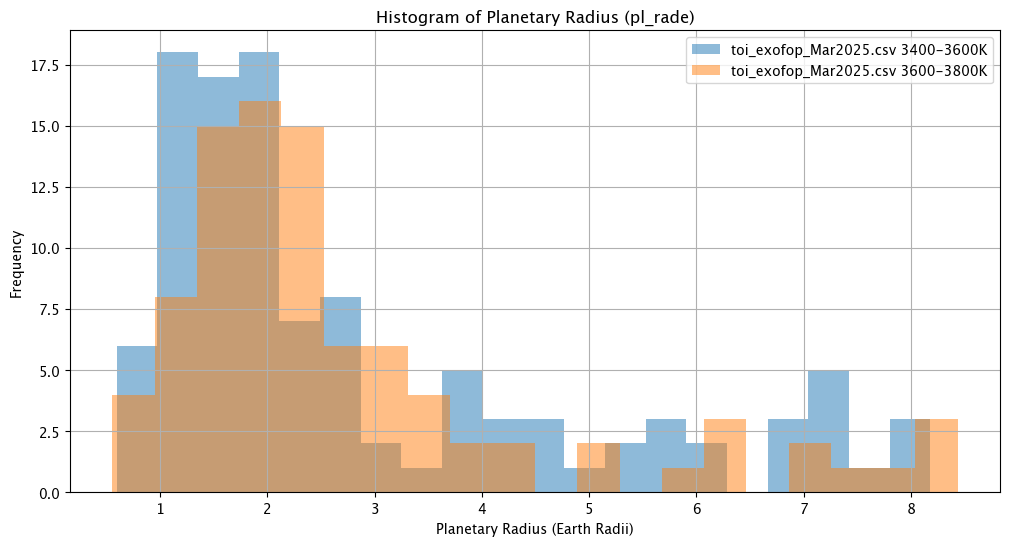

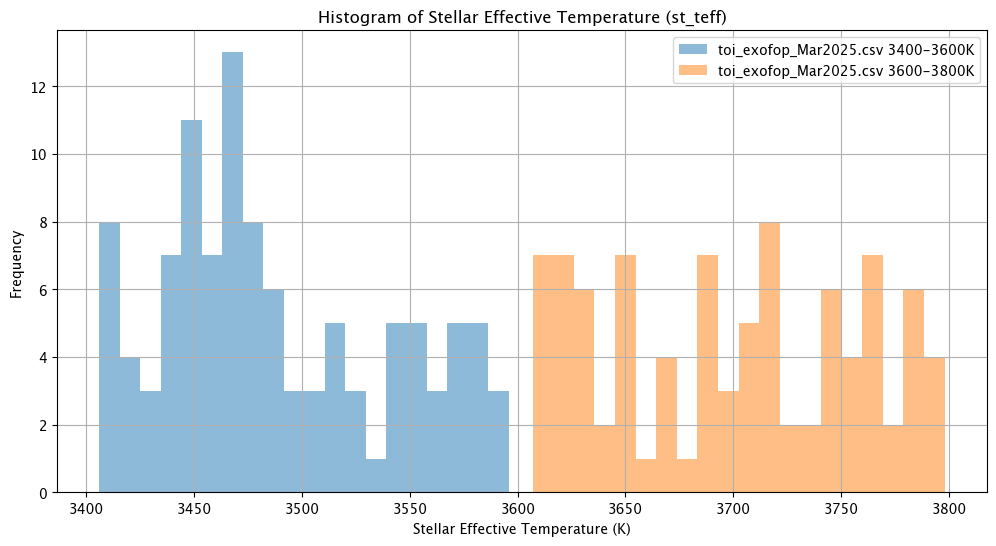

KeyError: 'pl_name'


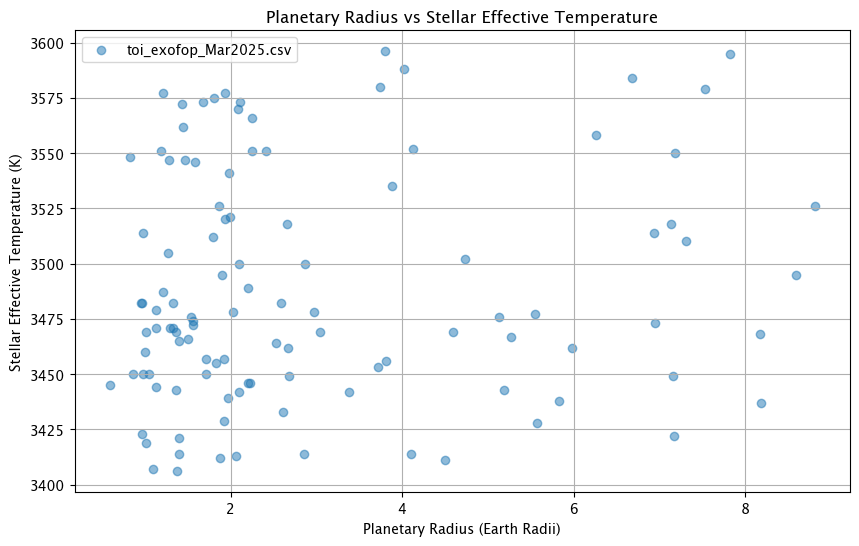

KeyError: 'pl_name'


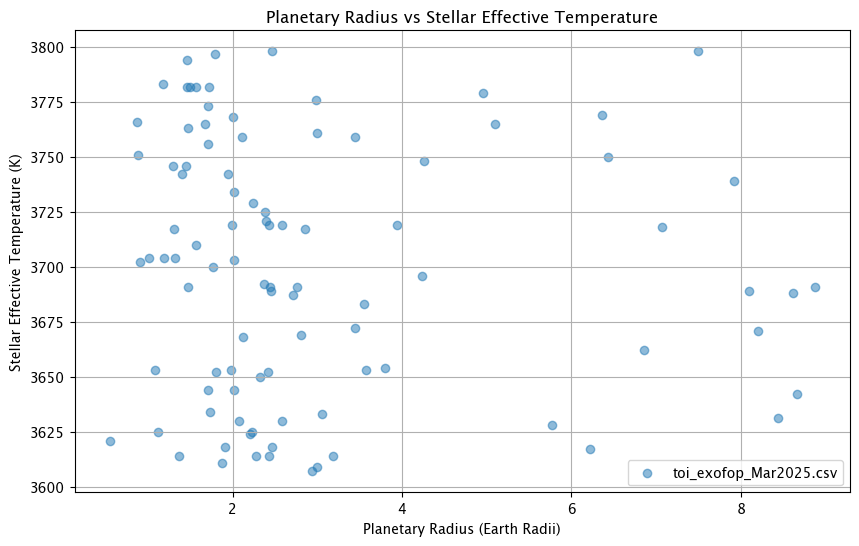

File 1: toi_exofop_Mar2025.csv
110 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
94 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.14197292069632494, P-value: 0.2293342044698784
KS Statistic for 'st_teff': 1.0, P-value: 3.3306690738754696e-16


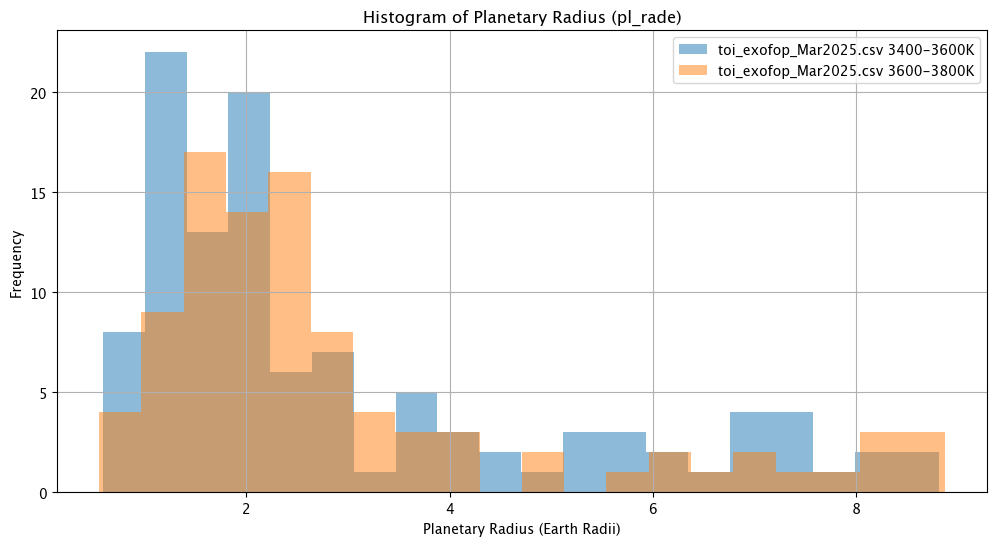

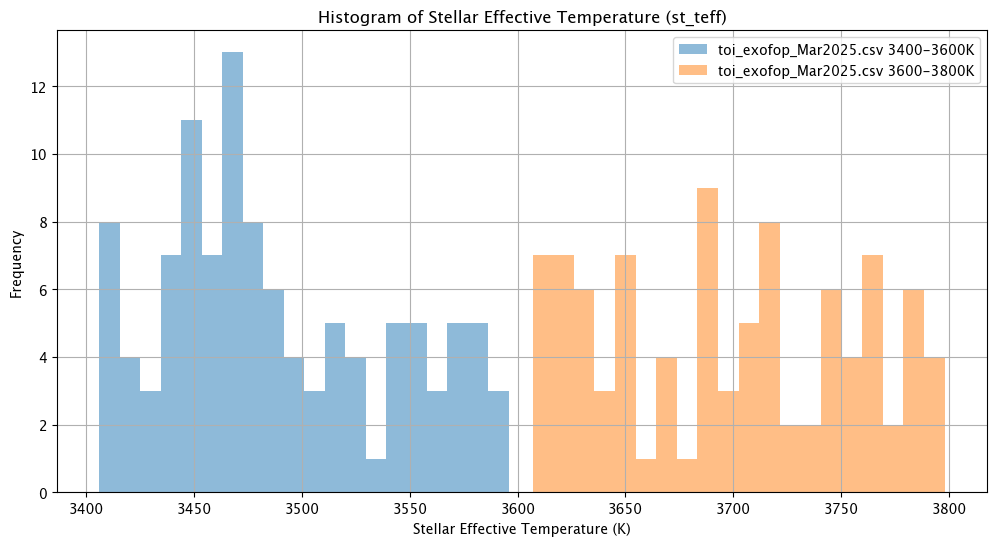

KeyError: 'pl_name'


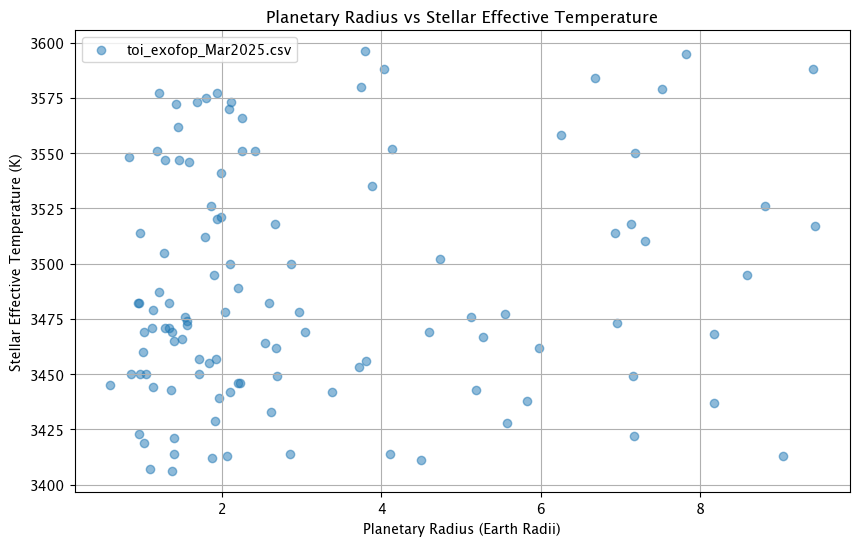

KeyError: 'pl_name'


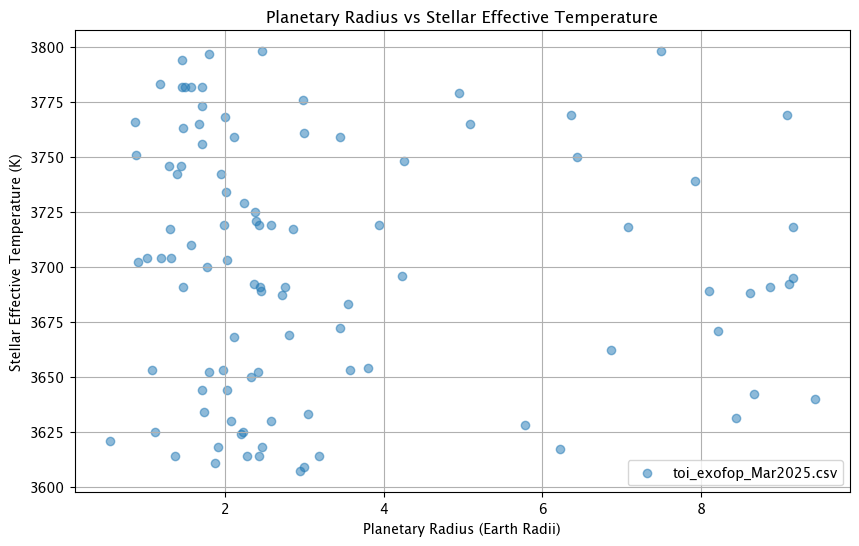

File 1: toi_exofop_Mar2025.csv
113 planets, Teff 3400 - 3600 K

File 2: toi_exofop_Mar2025.csv:
99 planets, Teff 3600 - 3800 K

KS Statistic for 'pl_rade': 0.1417716992938232, P-value: 0.21287345055540496
KS Statistic for 'st_teff': 1.0, P-value: 1.4432899320127035e-15


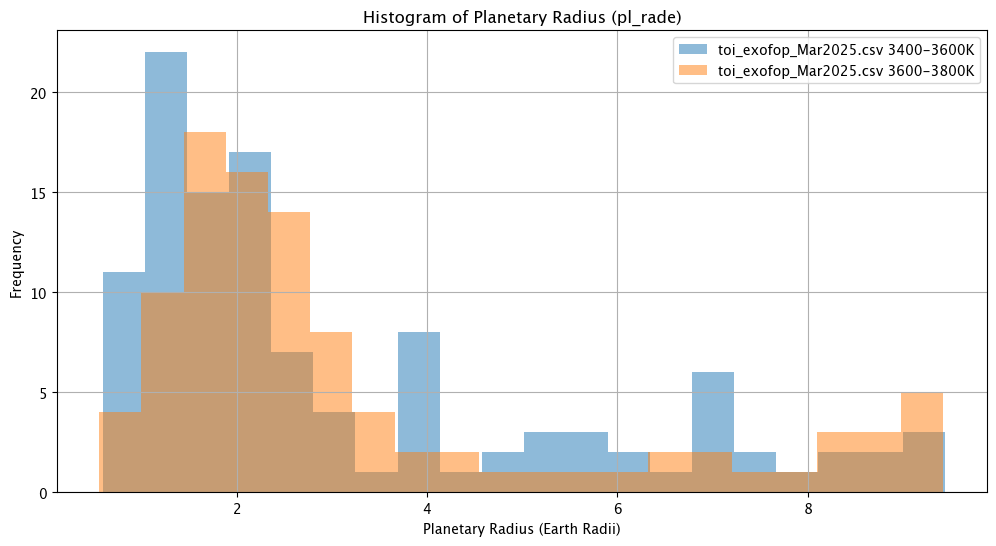

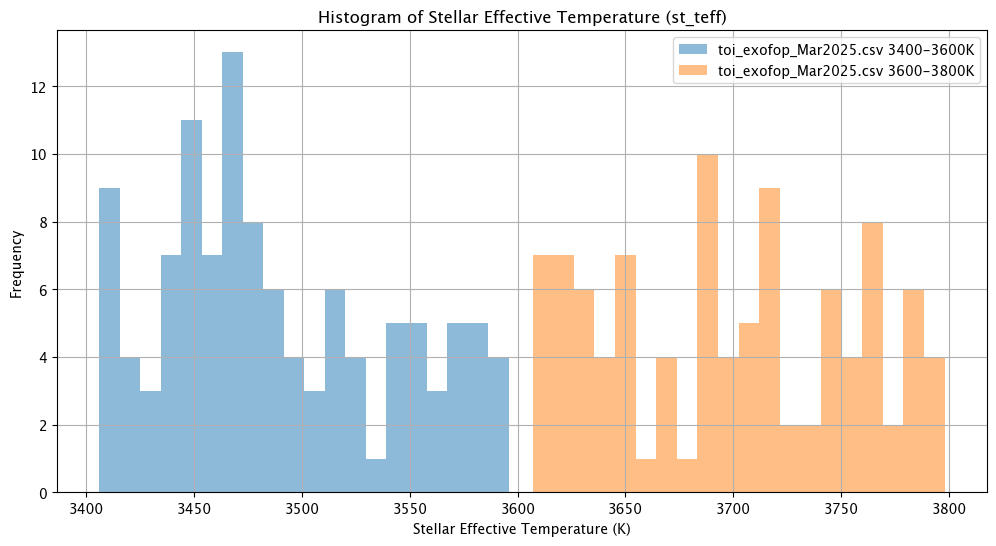

In [23]:
import os

def perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2):
    # Define the CSV file path
    csv_file_path = 'results_ks_test_toi_rmax.csv'

    # Check if the CSV file exists
    if os.path.exists(csv_file_path):
        # Load the existing results from the CSV file
        results_df = pd.read_csv(csv_file_path)
    else:
        # Create a new DataFrame if the CSV file does not exist
        results_df = pd.DataFrame(columns=['ks_statistic_rade', 'p_value_rade', 'ks_statistic_teff', 'p_value_teff', 'teff_min1', 'teff_max1', 'teff_min2', 'teff_max2', 'rad_min1', 'rad_max1', 'rad_min2', 'rad_max2', 'file_1_len', 'file_2_len'])

    ks_statistic_rade, p_value_rade, ks_statistic_teff, p_value_teff, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2, file_1_len, file_2_len = perform_ks_test('toi_exofop_Mar2025.csv', 0, 'toi_exofop_Mar2025.csv', 0, teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

    new_row = {
        'ks_statistic_rade': ks_statistic_rade,
        'p_value_rade': p_value_rade,
        'ks_statistic_teff': ks_statistic_teff,
        'p_value_teff': p_value_teff,
        'teff_min1': teff_min1,
        'teff_max1': teff_max1,
        'teff_min2': teff_min2,
        'teff_max2': teff_max2,
        'rad_min1': rad_min1,
        'rad_max1': rad_max1,
        'rad_min2': rad_min2,
        'rad_max2': rad_max2,
        'file_1_len': file_1_len,
        'file_2_len': file_2_len
    }

    if not ((results_df['ks_statistic_rade'] == new_row['ks_statistic_rade']) & 
        (results_df['p_value_rade'] == new_row['p_value_rade']) & 
        (results_df['ks_statistic_teff'] == new_row['ks_statistic_teff']) & 
        (results_df['p_value_teff'] == new_row['p_value_teff']) & 
        (results_df['teff_min1'] == new_row['teff_min1']) & 
        (results_df['teff_max1'] == new_row['teff_max1']) & 
        (results_df['teff_min2'] == new_row['teff_min2']) & 
        (results_df['teff_max2'] == new_row['teff_max2']) & 
        (results_df['rad_min1'] == new_row['rad_min1']) & 
        (results_df['rad_max1'] == new_row['rad_max1']) & 
        (results_df['rad_min2'] == new_row['rad_min2']) & 
        (results_df['rad_max2'] == new_row['rad_max2'])).any():
        results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)

    # Save the updated results to the CSV file
    results_df.to_csv(csv_file_path, index=False)
    return results_df

teff_min1 = 3400
teff_max1 = 3600
teff_min2 = 3600
teff_max2 = 3800

rad_min1 = 0
rad_min2 = 0

results_df = pd.DataFrame()

#LOOP
for rad_max in np.arange(1, 10, 0.5):
    rad_max1 = rad_max
    rad_max2 = rad_max
    results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

#SINGULAR
#results_df = perform_and_save_ks_test(teff_min1, teff_max1, teff_min2, teff_max2, rad_min1, rad_max1, rad_min2, rad_max2)

In [27]:
# Filter the results based on the defined ranges
def filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range):
    sample_results_df = results_df[(results_df['teff_min1'].between(*teff_min1_range)) & 
                                   (results_df['teff_max1'].between(*teff_max1_range)) & 
                                   (results_df['teff_min2'].between(*teff_min2_range)) & 
                                   (results_df['teff_max2'].between(*teff_max2_range)) & 
                                   (results_df['rad_min1'].between(*rad_min1_range)) & 
                                   (results_df['rad_max1'].between(*rad_max1_range)) & 
                                   (results_df['rad_min2'].between(*rad_min2_range)) & 
                                   (results_df['rad_max2'].between(*rad_max2_range))]

    # Print the ranges of effective temperature and planetary radius
    print("\nEffective Temperature and Planetary Radius Ranges:")
    print("Teff Min1:", sample_results_df['teff_min1'].unique())
    print("Teff Max1:", sample_results_df['teff_max1'].unique())
    print("Teff Min2:", sample_results_df['teff_min2'].unique())
    print("Teff Max2:", sample_results_df['teff_max2'].unique())
    print("Rad Min1:", sample_results_df['rad_min1'].unique())
    print("Rad Max1:", sample_results_df['rad_max1'].unique())
    print("Rad Min2:", sample_results_df['rad_min2'].unique())
    print("Rad Max2:", sample_results_df['rad_max2'].unique())

    # Create a new figure for the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(sample_results_df['rad_max1'], sample_results_df['ks_statistic_rade'], marker='o', linestyle='-', color='b', label='ks_statistic_rade')
    plt.scatter(sample_results_df['rad_max1'], sample_results_df['p_value_rade'], marker='o', linestyle='-', color='r', label='p_value_rade')
    plt.scatter(sample_results_df['rad_max1'], sample_results_df['file_1_len']/100, marker='o', linestyle='-', color='g', label='file_1_len/100')
    plt.scatter(sample_results_df['rad_max1'], sample_results_df['file_2_len']/100, marker='o', linestyle='-', color='y', label='file_2_len/100')
    plt.title('KS Statistic for Planetary Radius vs Maximum Radius')
    plt.xlabel('Maximum Planetary Radius (Earth Radii)')
    plt.ylabel('KS Statistic for Planetary Radius')
    plt.xlim(0,4)
    plt.grid(True)
    plt.legend()
    plt.show()

    return sample_results_df






Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3000]
Teff Max1: [3200]
Teff Min2: [3200]
Teff Max2: [3400]
Rad Min1: [0]
Rad Max1: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]
Rad Min2: [0]
Rad Max2: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]


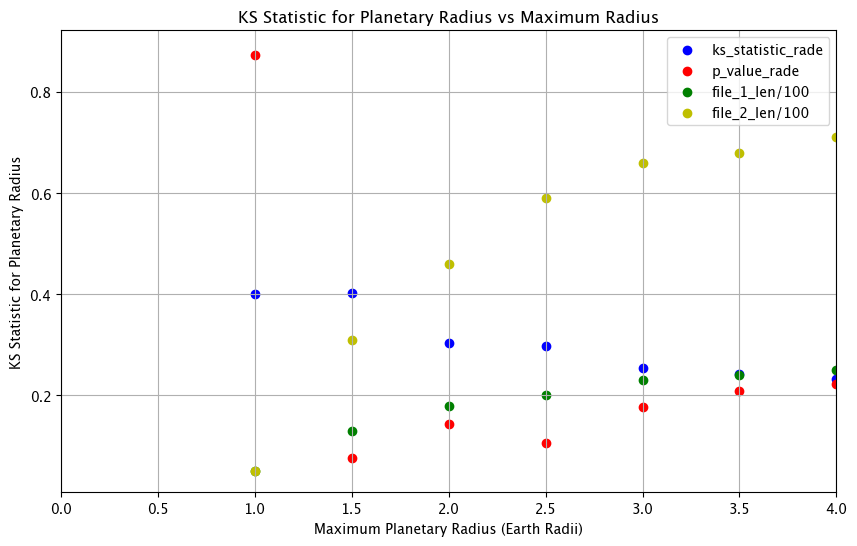

In [28]:
teff_min1_range = (3000, 3001)
teff_max1_range = (3200, 3201)
teff_min2_range = (3200, 3201)
teff_max2_range = (3400, 3401)
rad_min1_range = (0, 0.1)
rad_max1_range = (0, 10)
rad_min2_range = (0, 0.1)
rad_max2_range = (0, 10)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)
#call for the distribution of one point


Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3200]
Teff Max1: [3400]
Teff Min2: [3400]
Teff Max2: [3600]
Rad Min1: [0]
Rad Max1: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]
Rad Min2: [0]
Rad Max2: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]


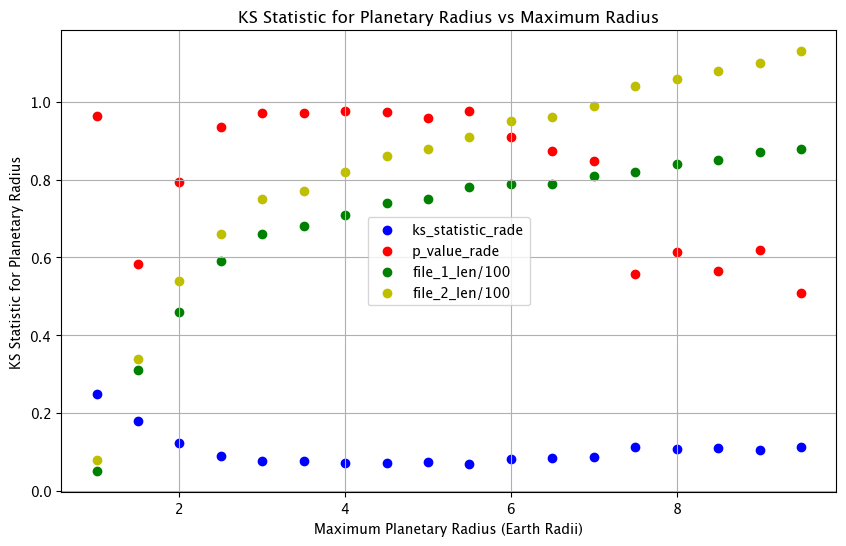

In [ ]:
teff_min1_range = (3200, 3201)
teff_max1_range = (3400, 3401)
teff_min2_range = (3400, 3401)
teff_max2_range = (3600, 3601)
rad_min1_range = (0, 0.1)
rad_max1_range = (0, 10)
rad_min2_range = (0, 0.1)
rad_max2_range = (0, 10)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)



Effective Temperature and Planetary Radius Ranges:
Teff Min1: [3400]
Teff Max1: [3600]
Teff Min2: [3600]
Teff Max2: [3800]
Rad Min1: [0]
Rad Max1: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]
Rad Min2: [0]
Rad Max2: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9.  9.5]


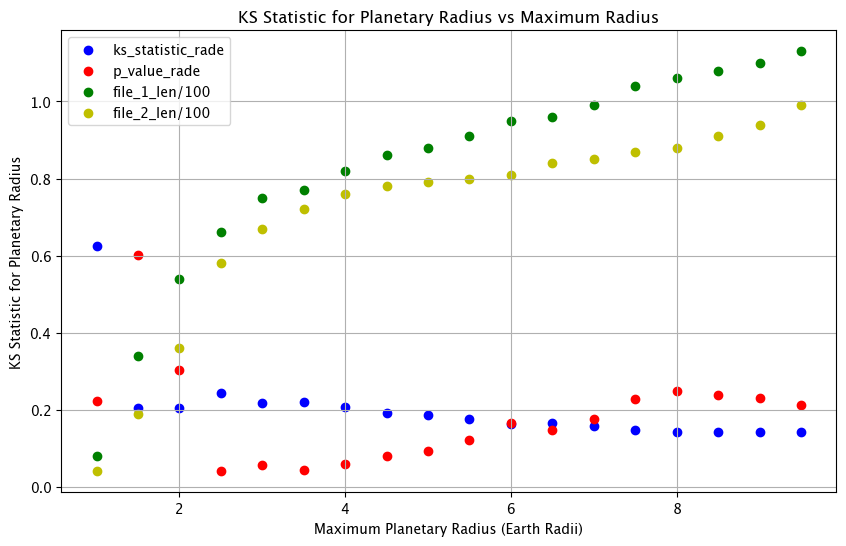

In [ ]:
teff_min1_range = (3400, 3401)
teff_max1_range = (3600, 3601)
teff_min2_range = (3600, 3601)
teff_max2_range = (3800, 3801)
rad_min1_range = (0, 0.1)
rad_max1_range = (0, 10)
rad_min2_range = (0, 0.1)
rad_max2_range = (0, 10)

sample_results_df = filter_and_plot_results(results_df, teff_min1_range, teff_max1_range, teff_min2_range, teff_max2_range, rad_min1_range, rad_max1_range, rad_min2_range, rad_max2_range)

#upward slope on the left is the detection bias